<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/ModelTraining_Optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# --- Imports & Constants ---
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from datetime import timedelta
import matplotlib.pyplot as plt
import os
# Optuna Imports
import optuna
from optuna.samplers import TPESampler # The default, advanced Bayesian-like sampler

# Paths & scope
OUTPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'
TEST_SET_DAYS = 60      # Last 2 months for final evaluation

# Optimization Constants
MAPE_EPSILON = 1e-6
MIN_TRAIN_DAYS = 180

# Targets (raw only)
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

# Features
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

# Cross-validation Defaults
N_SPLITS = 2
VAL_DAYS = 90

# Storage
test_predictions_list = []
feature_importance_dict = {}
cv_results_list = []
optuna_final_comparison_results = [] # Storage for Optuna results

# Global variables to pass data and CV object to the Optuna objective function
X_TRAIN_FULL_GLOBAL = None
Y_TRAIN_FULL_GLOBAL = None
TSCV_GLOBAL = None
RAW_TARGET_COL_GLOBAL = None
NUMERIC_FEATURES_GLOBAL = None
CATEGORICAL_FEATURES_GLOBAL = None

In [4]:
# --- Utility Functions (Identical to Original Code) ---

def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    """Adds lag and rolling features for target columns."""
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    df.fillna(0, inplace=True)
    return df

def dynamic_weights(y_val_raw, y_pred_xgb, y_pred_ridge):
    """Computes fold-specific ensemble weights via validation RMSE."""
    rmse_xgb = np.sqrt(mean_squared_error(y_val_raw, y_pred_xgb))
    rmse_ridge = np.sqrt(mean_squared_error(y_val_raw, y_pred_ridge))
    total = rmse_xgb + rmse_ridge if (rmse_xgb + rmse_ridge) > 0 else 1.0
    w_xgb = 1 - (rmse_xgb / total)
    w_ridge = 1 - w_xgb
    return w_xgb, w_ridge

def plot_test_results(test_df, center_name, meal_period):
    # ... (Plotting function content is omitted for brevity, but remains unchanged) ...
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o', linestyle='-')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x', linestyle='--')
    plt.title(f'Actual vs. Predicted Revenue (Test Set) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue')
    plt.legend(); plt.grid(True, alpha=0.5); plt.xticks(rotation=45)
    plt.tight_layout(); plt.show()

def plot_residuals_over_time(residuals_df, center_name, meal_period):
    # ... (Plotting function content is omitted for brevity, but remains unchanged) ...
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    mean_residual = residuals_df['Residual'].mean()
    plt.axhline(mean_residual, color='blue', linestyle='-', linewidth=1, label=f'Mean Residual: {mean_residual:.2f}')
    plt.title(f'Test Set Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual (Actual - Predicted)')
    plt.legend(); plt.grid(True, alpha=0.5); plt.xticks(rotation=45)
    plt.tight_layout(); plt.show()

def plot_cv_rmse_comparison(cv_results_list):
    # ... (Plotting function content is omitted for brevity, but remains unchanged) ...
    df_cv = pd.DataFrame(cv_results_list)
    if df_cv.empty:
        print("No CV results to plot.")
        return
    df_cv['Center_Meal'] = df_cv['Center'].astype(str) + ' - ' + df_cv['Meal']
    df_pivot = df_cv.pivot(index='Center_Meal', columns='Fold', values='RMSE')
    plt.figure(figsize=(14, 7))
    df_pivot.plot(kind='bar', figsize=(14, 7), width=0.8)
    plt.title('Fold-by-Fold RMSE Comparison Across All Models')
    plt.ylabel('RMSE (Raw Scale)')
    plt.xlabel('Revenue Center - Meal Period')
    plt.xticks(rotation=45, ha='right'); plt.legend(title='CV Fold')
    plt.grid(axis='y', alpha=0.5); plt.tight_layout(); plt.show()

In [5]:
# --- 1. Optuna Objective Function (Minimizes RMSE) ---

def objective(trial):
    """
    Optuna's objective function runs the Time Series Cross-Validation
    for the hyperparameters suggested by the trial.
    """
    # 🎯 Define the identical search space using trial.suggest_*
    lr = trial.suggest_float('learning_rate', 0.001, 0.02, log=True)
    md = trial.suggest_int('max_depth', 3, 8)
    # Match the robust, log-uniform alpha space (0.01 to 500.0)
    alpha = trial.suggest_float('ridge_alpha', 0.01, 500.0, log=True)

    current_xgb_params = {
        'objective': 'reg:squarederror',
        'learning_rate': lr,
        'max_depth': md,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': 42
    }
    current_ridge_alpha = alpha
    fold_rmses = []

    # Use global data passed from train_and_forecast_center
    X_train_full = X_TRAIN_FULL_GLOBAL
    Y_train_full = Y_TRAIN_FULL_GLOBAL
    tscv = TSCV_GLOBAL
    raw_target_col = RAW_TARGET_COL_GLOBAL
    numeric_features = NUMERIC_FEATURES_GLOBAL
    categorical_features = CATEGORICAL_FEATURES_GLOBAL

    # Run CV for the current trial's parameter combination
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):

        X_train_cv, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        Y_train_cv, Y_val = Y_train_full.iloc[train_idx][raw_target_col], Y_train_full.iloc[val_idx][raw_target_col]

        # Scaling and DMatrix preparation (identical logic)
        scaler = StandardScaler()
        X_train_num = pd.DataFrame(scaler.fit_transform(X_train_cv[numeric_features]), columns=numeric_features, index=X_train_cv.index)
        X_val_num = pd.DataFrame(scaler.transform(X_val[numeric_features]), columns=numeric_features, index=X_val.index)
        X_train_cv_scaled = pd.concat([X_train_num, X_train_cv[categorical_features]], axis=1)
        X_val_scaled = pd.concat([X_val_num, X_val[categorical_features]], axis=1)

        dtrain = xgb.DMatrix(X_train_cv_scaled.values, label=Y_train_cv, feature_names=list(X_train_cv_scaled.columns))
        dval = xgb.DMatrix(X_val_scaled.values, label=Y_val, feature_names=list(X_val_scaled.columns))

        # Train XGB
        es_xgb_model = xgb.train(current_xgb_params, dtrain, num_boost_round=5000, evals=[(dval, 'validation')], early_stopping_rounds=100, verbose_eval=False)
        y_pred_xgb = es_xgb_model.predict(dval)

        # Train Ridge
        best_ridge_model = Ridge(alpha=current_ridge_alpha, random_state=42).fit(X_train_cv_scaled, Y_train_cv)
        y_pred_ridge = best_ridge_model.predict(X_val_scaled)

        # Ensemble and metric
        w_xgb, w_ridge = dynamic_weights(Y_val, y_pred_xgb, y_pred_ridge)
        y_pred_val_ens = (w_xgb * y_pred_xgb) + (w_ridge * y_pred_ridge)
        rmse = np.sqrt(mean_squared_error(Y_val, y_pred_val_ens))
        fold_rmses.append(rmse)

    # Optuna minimizes the mean RMSE across folds
    return np.mean(fold_rmses)

In [6]:
# --- 2. Main Training Function (Optuna Optimized) ---

def train_and_forecast_center(df_center, center_name):
    """
    Runs feature engineering, Optuna optimization, and final test evaluation.
    """
    global X_TRAIN_FULL_GLOBAL, Y_TRAIN_FULL_GLOBAL, TSCV_GLOBAL, RAW_TARGET_COL_GLOBAL
    global NUMERIC_FEATURES_GLOBAL, CATEGORICAL_FEATURES_GLOBAL

    # Feature Engineering (IDENTICAL)
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"ERROR: Center {center_name} data is insufficient for split.")
        return

    # Dynamic CV Adjustment (IDENTICAL)
    data_length = len(df_train_full)
    if data_length < (MIN_TRAIN_DAYS + VAL_DAYS * N_SPLITS):
        new_val_days = max(15, int(data_length * 0.1))
        new_n_splits = max(1, int((data_length - new_val_days) / MIN_TRAIN_DAYS))
        tscv = TimeSeriesSplit(n_splits=new_n_splits, test_size=new_val_days)
        print(f"⚠️ Adjusted CV for small data ({center_name}): n_splits={new_n_splits}, test_size={new_val_days}")
    else:
        tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS)

    feature_cols = [c for c in df_center.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_center[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]
    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    # Store data globally for Optuna to access
    X_TRAIN_FULL_GLOBAL = X_train_full
    Y_TRAIN_FULL_GLOBAL = Y_train_full
    TSCV_GLOBAL = tscv
    NUMERIC_FEATURES_GLOBAL = numeric_features
    CATEGORICAL_FEATURES_GLOBAL = categorical_features

    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')
        RAW_TARGET_COL_GLOBAL = raw_target_col

        print(f"\n🧠 Starting Optuna Optimization (TPE) for {center_name} - {meal_period}")

        # --- Run Optuna Study ---
        sampler = TPESampler(seed=42) # Ensure reproducibility
        study = optuna.create_study(direction='minimize', sampler=sampler)

        # Run 50 trials, matching the n_calls=50 used in skopt
        study.optimize(objective, n_trials=50, show_progress_bar=False)

        best_trial = study.best_trial
        best_lr = best_trial.params['learning_rate']
        best_md = best_trial.params['max_depth']
        best_alpha = best_trial.params['ridge_alpha']
        best_avg_rmse = best_trial.value

        print(f"✅ Best parameters found: LR={best_lr:.5f}, MD={best_md}, Alpha={best_alpha:.2f}. Min Avg CV RMSE: {best_avg_rmse:.2f}")

        optuna_final_comparison_results.append({
            'Center': center_name, 'Meal': meal_period, 'Method': 'Optuna TPE',
            'Best_LR': best_lr, 'Best_MD': best_md, 'Best_Alpha': best_alpha,
            'Avg_CV_RMSE': best_avg_rmse
        })

        # --- Final Retraining and Evaluation (identical logic) ---
        last_model_xgb = None
        last_weights = (0.5, 0.5)

        # Rerun CV with the BEST parameters to get the final models/weights
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):
            # ... (Scaling and preparation code) ...
            X_train_cv, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
            Y_train_cv, Y_val = Y_train_full.iloc[train_idx][raw_target_col], Y_train_full.iloc[val_idx][raw_target_col]

            scaler = StandardScaler()
            X_train_num = pd.DataFrame(scaler.fit_transform(X_train_cv[numeric_features]), columns=numeric_features, index=X_train_cv.index)
            X_val_num = pd.DataFrame(scaler.transform(X_val[numeric_features]), columns=numeric_features, index=X_val.index)
            X_train_cv_scaled = pd.concat([X_train_num, X_train_cv[categorical_features]], axis=1)
            X_val_scaled = pd.concat([X_val_num, X_val[categorical_features]], axis=1)

            dtrain = xgb.DMatrix(X_train_cv_scaled.values, label=Y_train_cv, feature_names=list(X_train_cv_scaled.columns))
            dval = xgb.DMatrix(X_val_scaled.values, label=Y_val, feature_names=list(X_val_scaled.columns))

            current_xgb_params = {'objective': 'reg:squarederror', 'learning_rate': best_lr, 'max_depth': best_md, 'subsample': 0.8, 'colsample_bytree': 0.8, 'seed': 42}

            es_xgb_model = xgb.train(current_xgb_params, dtrain, num_boost_round=5000, evals=[(dval, 'validation')], early_stopping_rounds=100, verbose_eval=False)
            best_ridge_model = Ridge(alpha=best_alpha, random_state=42).fit(X_train_cv_scaled, Y_train_cv)

            if fold == tscv.n_splits - 1:
                last_model_xgb = es_xgb_model
                y_pred_xgb = es_xgb_model.predict(dval)
                y_pred_ridge = best_ridge_model.predict(X_val_scaled)
                last_weights = dynamic_weights(Y_val, y_pred_xgb, y_pred_ridge)

                y_pred_val_ens = (last_weights[0] * y_pred_xgb) + (last_weights[1] * y_pred_ridge)
                rmse = np.sqrt(mean_squared_error(Y_val, y_pred_val_ens))
                cv_results_list.append({'Center': center_name, 'Meal': meal_period, 'Fold': fold + 1, 'RMSE': rmse})

                if not f'{center_name}_{meal_period}' in feature_importance_dict:
                    fi = es_xgb_model.get_score(importance_type='weight')
                    feature_importance_dict[f'{center_name}_{meal_period}'] = pd.Series(fi).sort_values(ascending=False)

        # 6) Final model training on full data
        num_round = getattr(last_model_xgb, 'best_iteration', 500)
        final_scaler = StandardScaler()
        X_train_full_num = pd.DataFrame(final_scaler.fit_transform(X_train_full[numeric_features]), columns=numeric_features, index=X_train_full.index)
        X_train_final = pd.concat([X_train_full_num, df_train_full[categorical_features]], axis=1)
        dtrain_full = xgb.DMatrix(X_train_final.values, label=Y_train_full[raw_target_col], feature_names=list(X_train_final.columns))
        final_xgb_model = xgb.train(current_xgb_params, dtrain_full, num_boost_round=num_round, verbose_eval=False)
        final_ridge_model = Ridge(alpha=best_alpha, random_state=42).fit(X_train_final, Y_train_full[raw_target_col])

        # 7) Test evaluation (IDENTICAL)
        X_test_num = pd.DataFrame(final_scaler.transform(df_test_full[numeric_features]), columns=numeric_features, index=df_test_full.index)
        X_test = pd.concat([X_test_num, df_test_full[categorical_features]], axis=1)
        dtest = xgb.DMatrix(X_test.values, feature_names=list(X_test.columns))
        Y_test_current = df_test_full[raw_target_col]

        y_test_xgb = final_xgb_model.predict(dtest)
        y_test_ridge = final_ridge_model.predict(X_test)
        w_xgb, w_ridge = last_weights
        y_test_ens = (w_xgb * y_test_xgb) + (w_ridge * y_test_ridge)

        test_rmse = np.sqrt(mean_squared_error(Y_test_current, y_test_ens))
        test_mape = np.mean(np.abs(Y_test_current - y_test_ens) / np.maximum(Y_test_current, MAPE_EPSILON)) * 100

        print(f"\n--- FINAL TEST SET RESULTS ({center_name} - {meal_period}) ---")
        print(f"TEST RMSE: {test_rmse:.2f}, TEST MAPE: {test_mape:.2f}%")

        plot_df = pd.DataFrame({'Date': df_test_full['Date'], 'Actual_Revenue': Y_test_current, 'Predicted_Revenue': y_test_ens})
        test_predictions_list.append(plot_df.assign(Revenue_Center=center_name, Meal_Period=meal_period))
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)

--- STARTING EXECUTION: Optuna Optimization (TPE Sampler) ---
✅ SUCCESS: Loaded 9 revenue centers (sheets).

🧠 Starting Optuna Optimization (TPE) for 1 - BreakFast
✅ Best parameters found: LR=0.00746, MD=3, Alpha=0.06. Min Avg CV RMSE: 882.10

--- FINAL TEST SET RESULTS (1 - BreakFast) ---
TEST RMSE: 1005.40, TEST MAPE: 549929485.89%


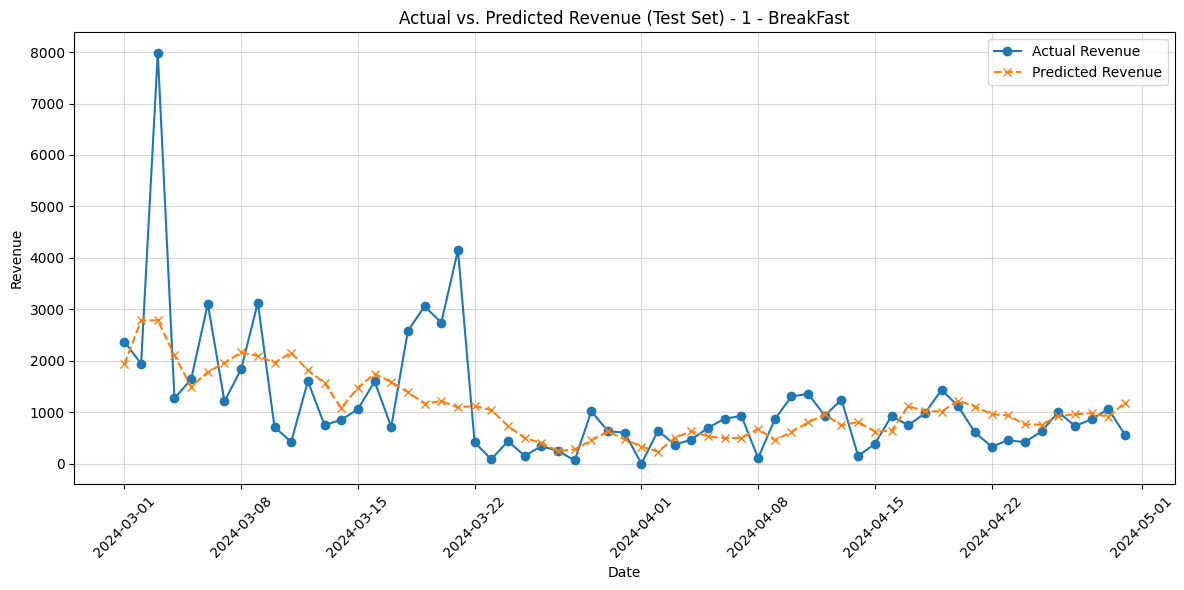

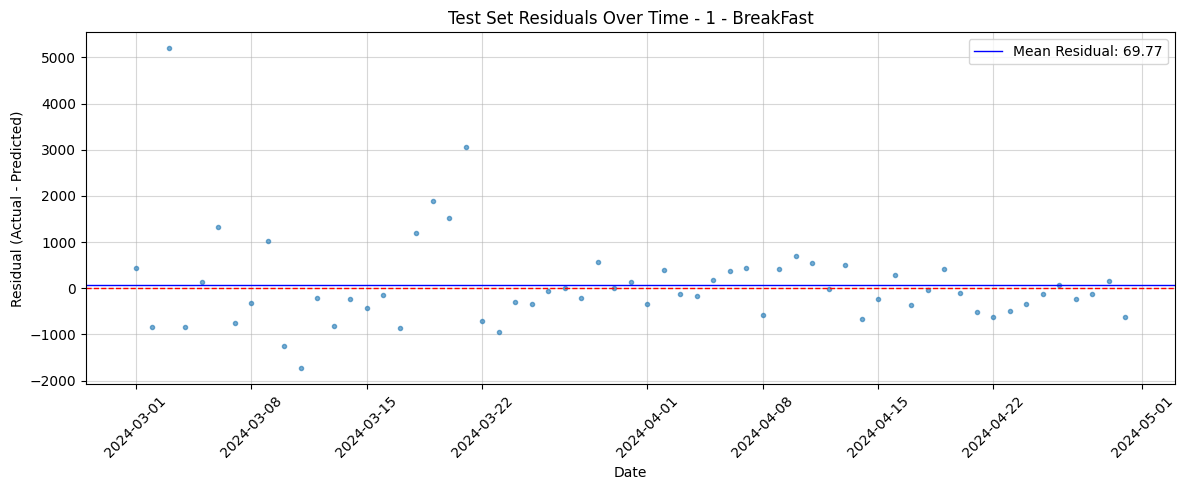


🧠 Starting Optuna Optimization (TPE) for 1 - Dinner
✅ Best parameters found: LR=0.01633, MD=3, Alpha=0.02. Min Avg CV RMSE: 1471.74

--- FINAL TEST SET RESULTS (1 - Dinner) ---
TEST RMSE: 1576.05, TEST MAPE: 64.23%


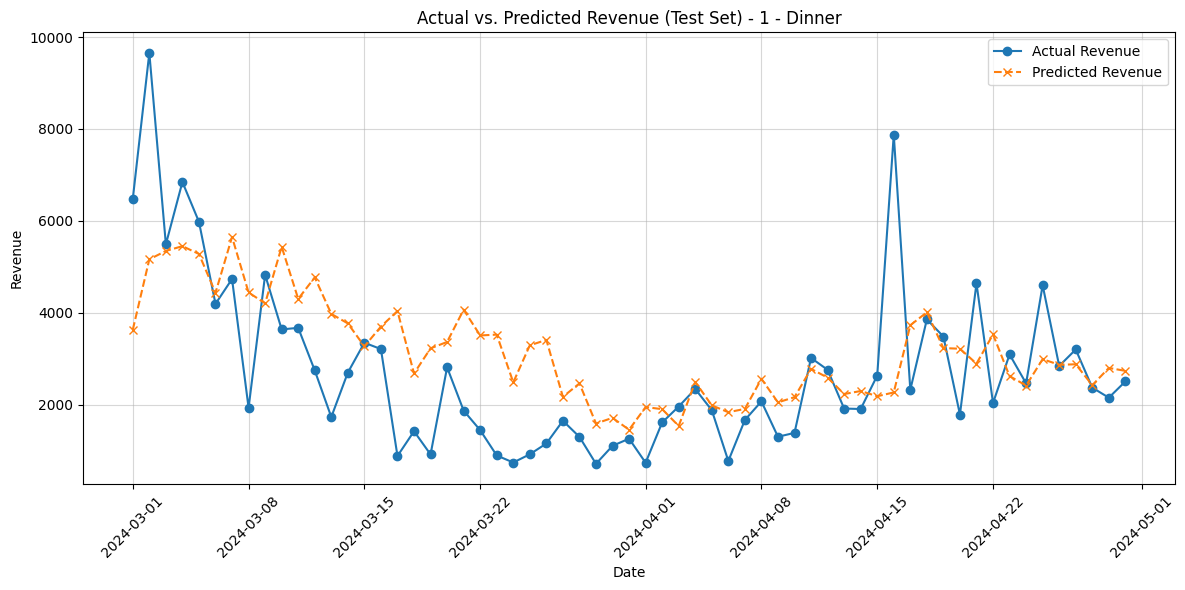

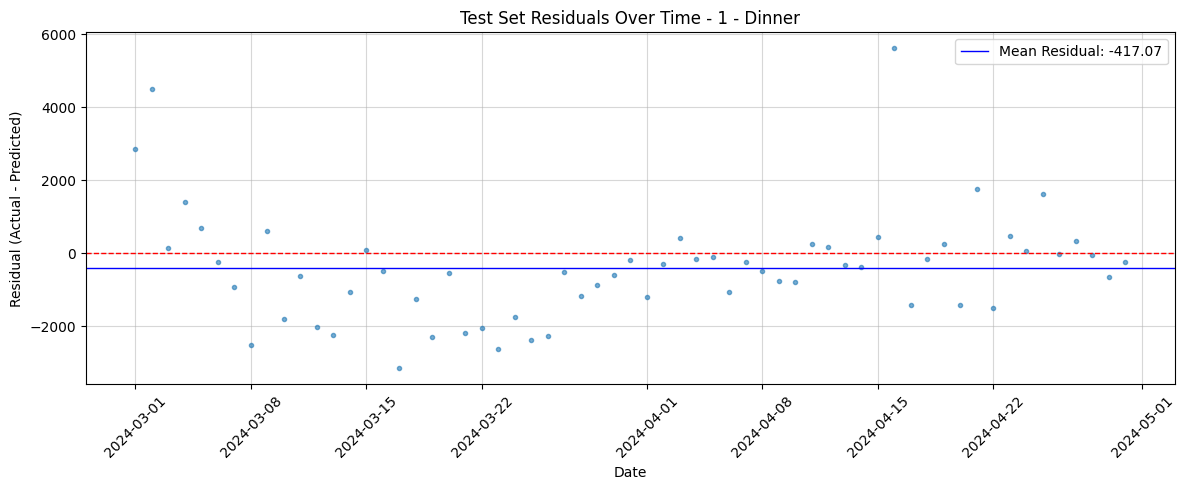


🧠 Starting Optuna Optimization (TPE) for 1 - Lunch
✅ Best parameters found: LR=0.00189, MD=8, Alpha=0.24. Min Avg CV RMSE: 767.26

--- FINAL TEST SET RESULTS (1 - Lunch) ---
TEST RMSE: 696.73, TEST MAPE: 2301276696.71%


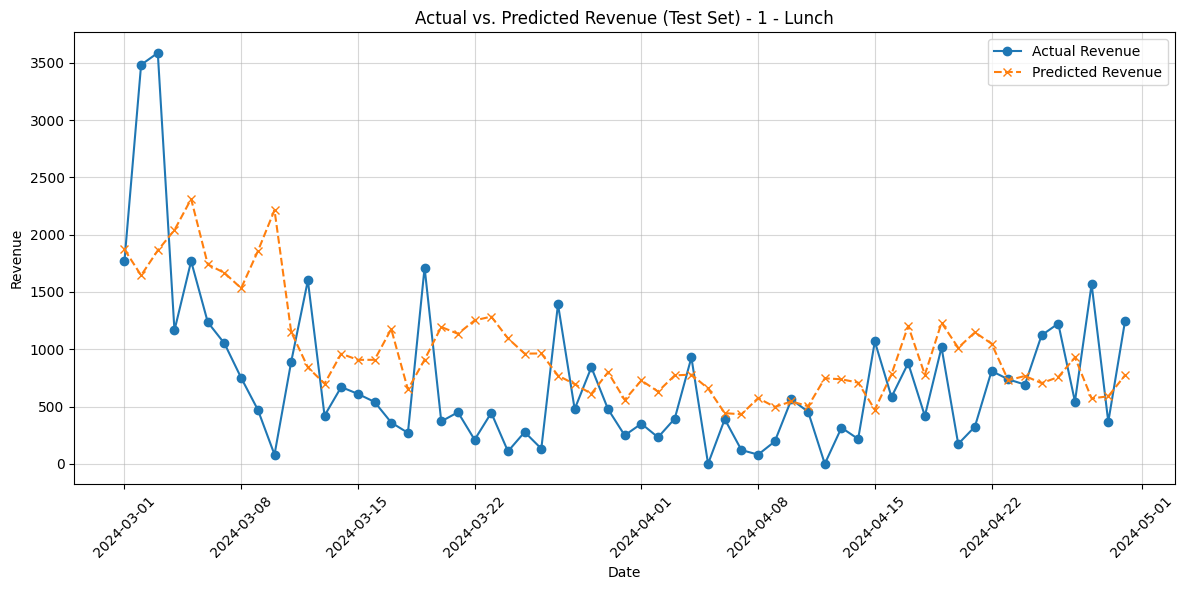

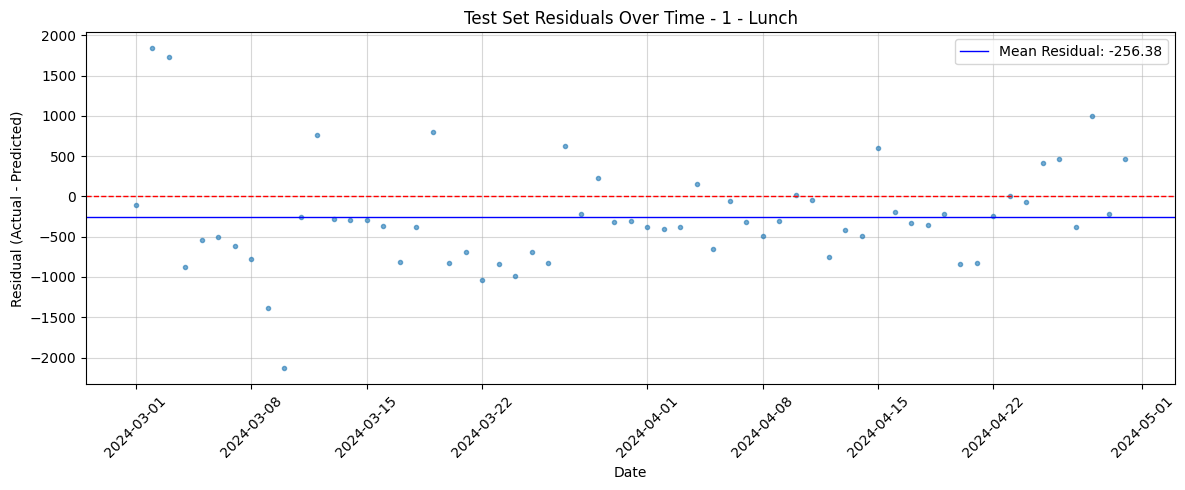


🧠 Starting Optuna Optimization (TPE) for 2 - BreakFast
✅ Best parameters found: LR=0.00932, MD=5, Alpha=415.04. Min Avg CV RMSE: 349.76

--- FINAL TEST SET RESULTS (2 - BreakFast) ---
TEST RMSE: 478.07, TEST MAPE: 10533330667.01%


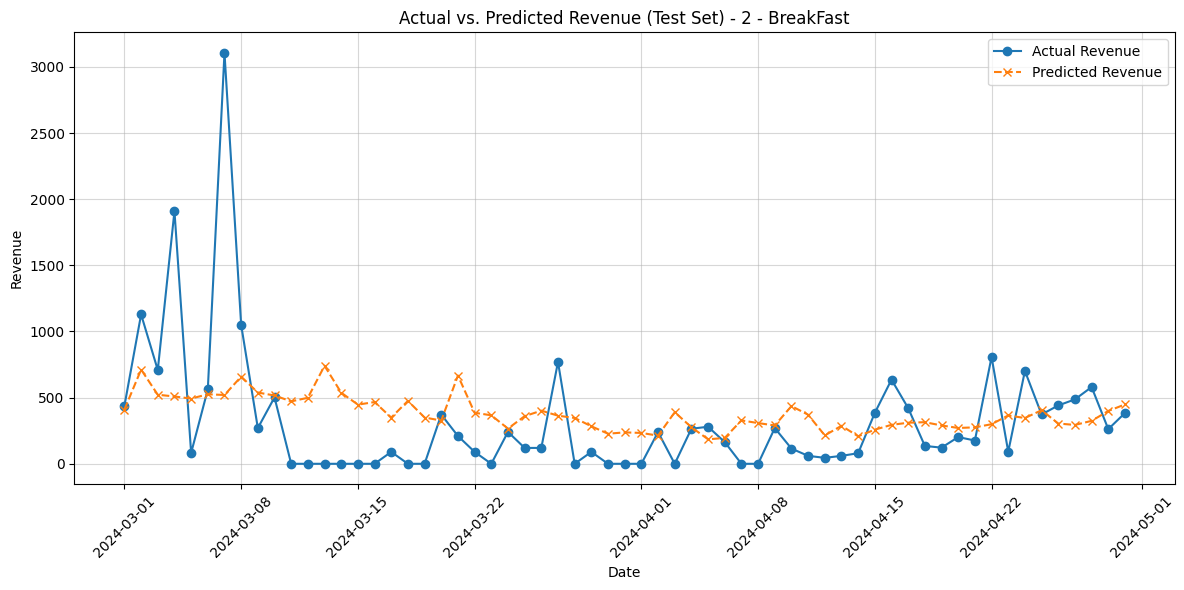

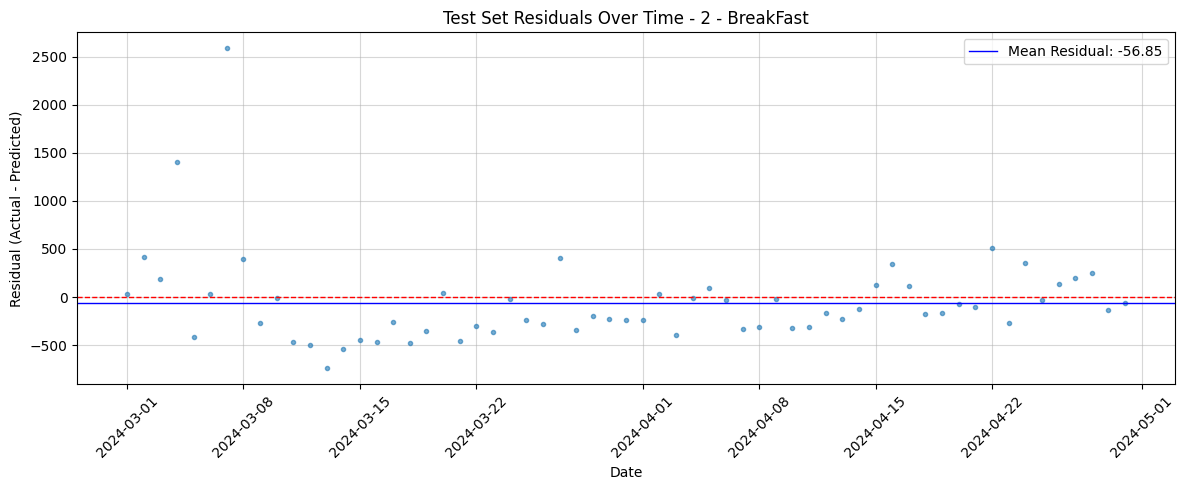


🧠 Starting Optuna Optimization (TPE) for 2 - Dinner
✅ Best parameters found: LR=0.00586, MD=8, Alpha=10.70. Min Avg CV RMSE: 868.76

--- FINAL TEST SET RESULTS (2 - Dinner) ---
TEST RMSE: 788.01, TEST MAPE: 9478481026.24%


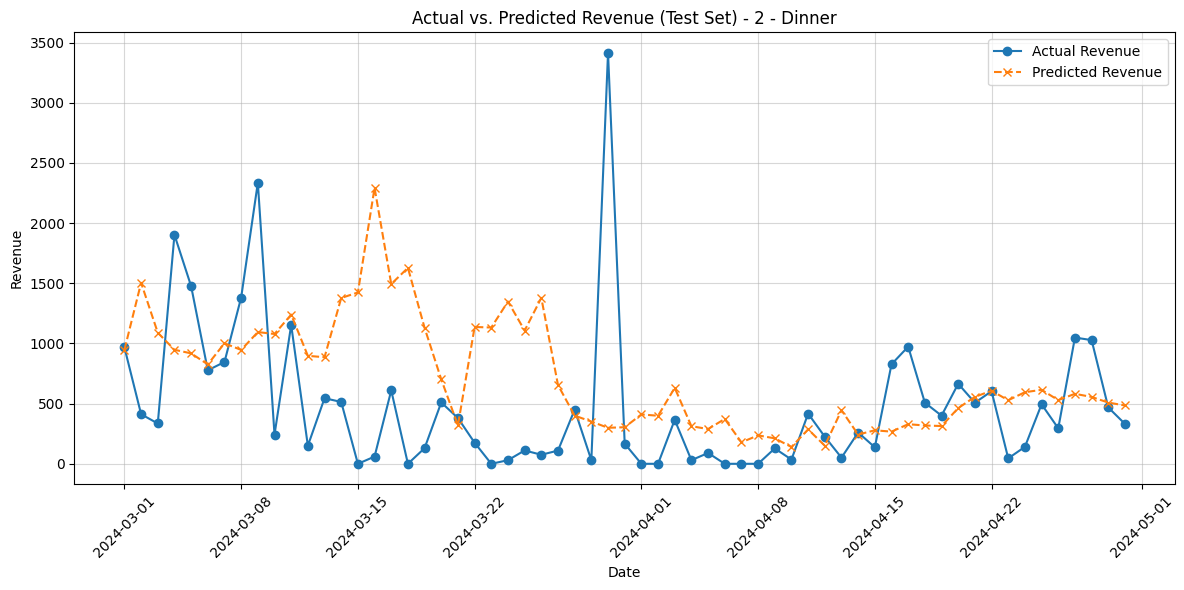

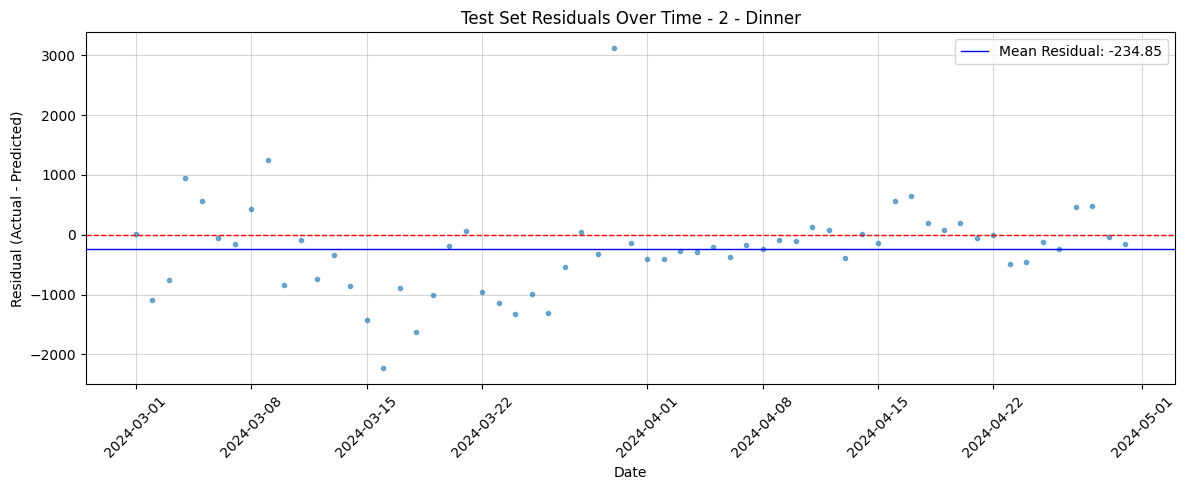


🧠 Starting Optuna Optimization (TPE) for 2 - Lunch
✅ Best parameters found: LR=0.01633, MD=3, Alpha=0.02. Min Avg CV RMSE: 420.44

--- FINAL TEST SET RESULTS (2 - Lunch) ---
TEST RMSE: 914.06, TEST MAPE: 3436313374.34%


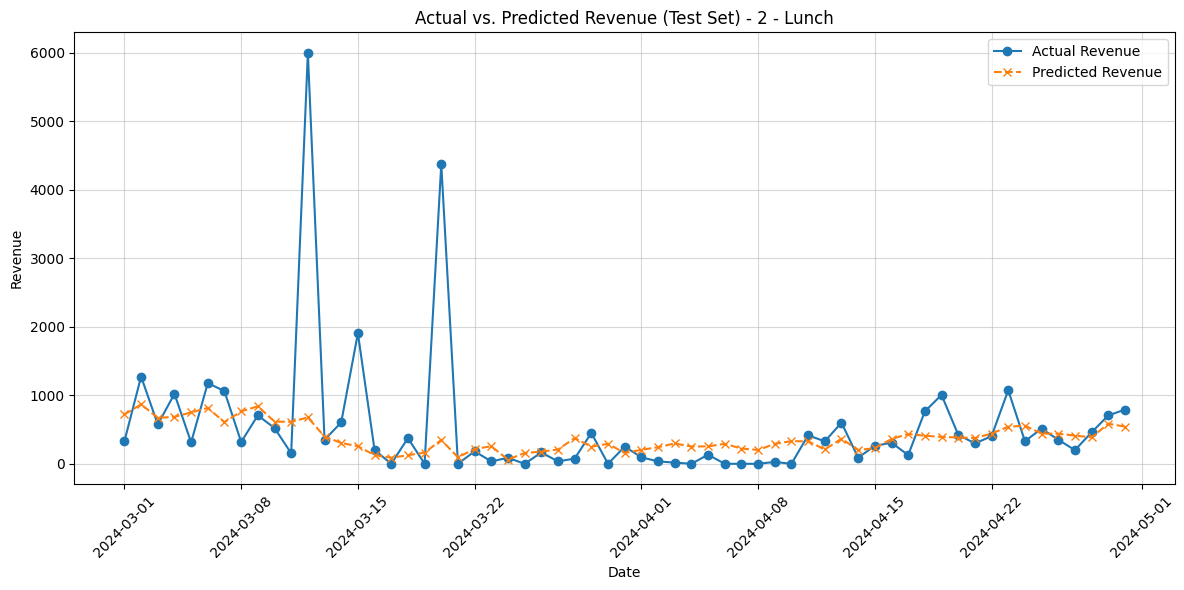

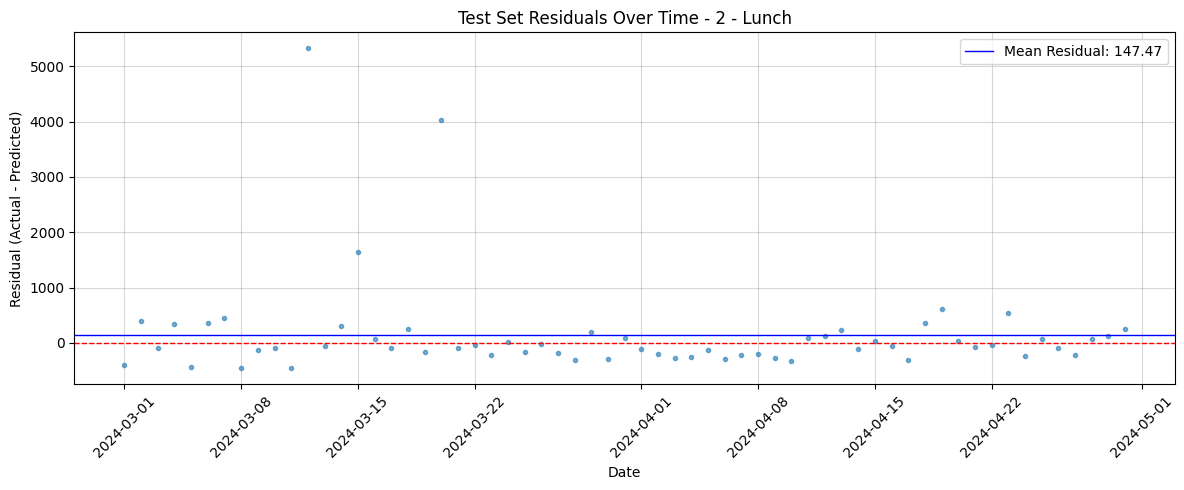


🧠 Starting Optuna Optimization (TPE) for 3 - BreakFast
✅ Best parameters found: LR=0.01319, MD=3, Alpha=490.00. Min Avg CV RMSE: 366.02

--- FINAL TEST SET RESULTS (3 - BreakFast) ---
TEST RMSE: 314.07, TEST MAPE: 8380470178.16%


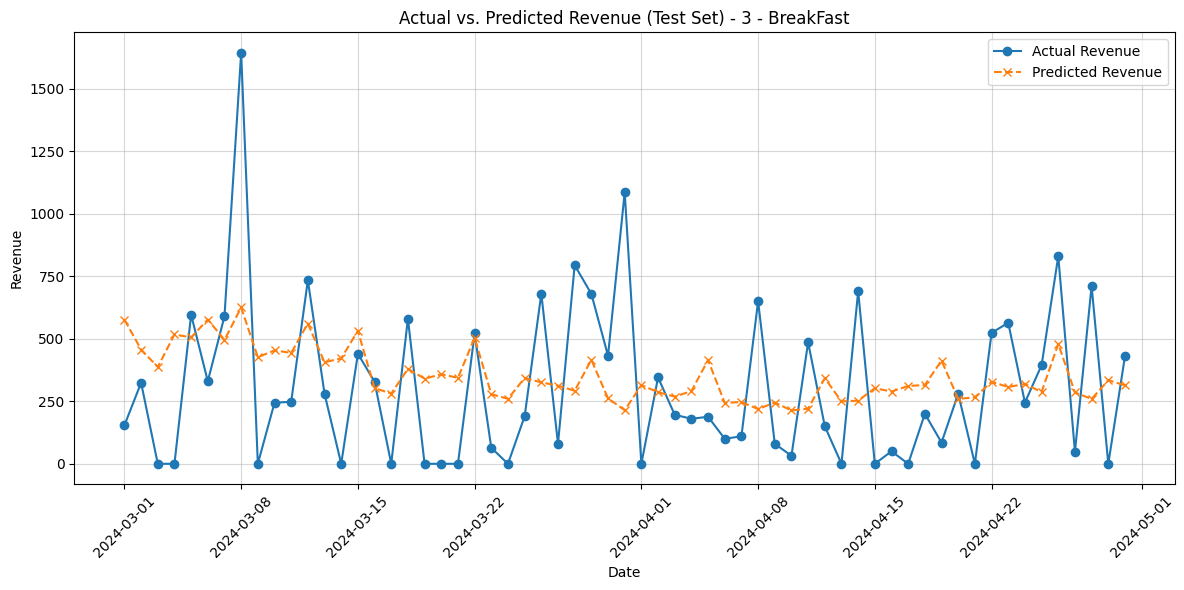

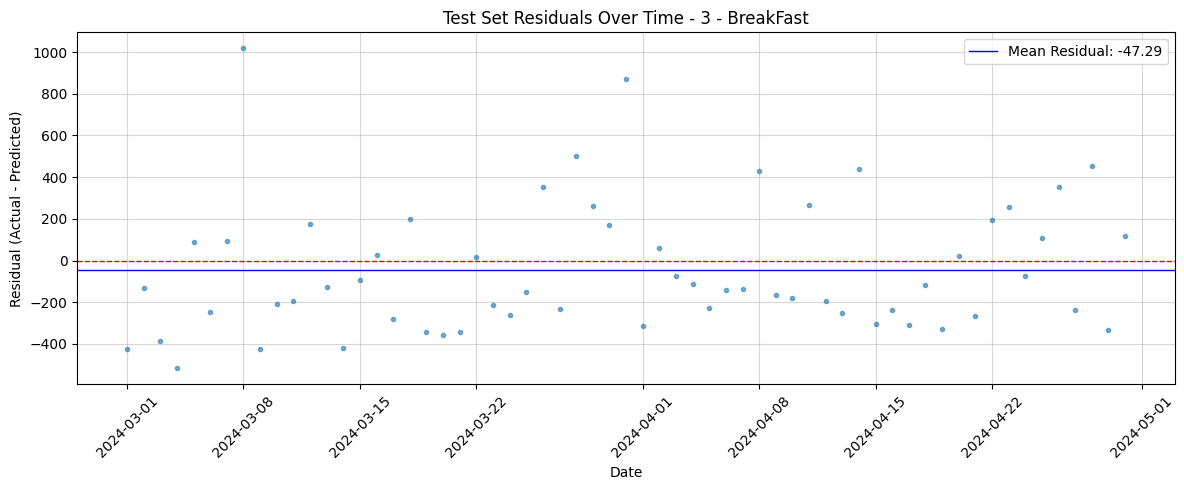


🧠 Starting Optuna Optimization (TPE) for 3 - Dinner
✅ Best parameters found: LR=0.01478, MD=5, Alpha=0.01. Min Avg CV RMSE: 4280.25

--- FINAL TEST SET RESULTS (3 - Dinner) ---
TEST RMSE: 8342.37, TEST MAPE: 40.54%


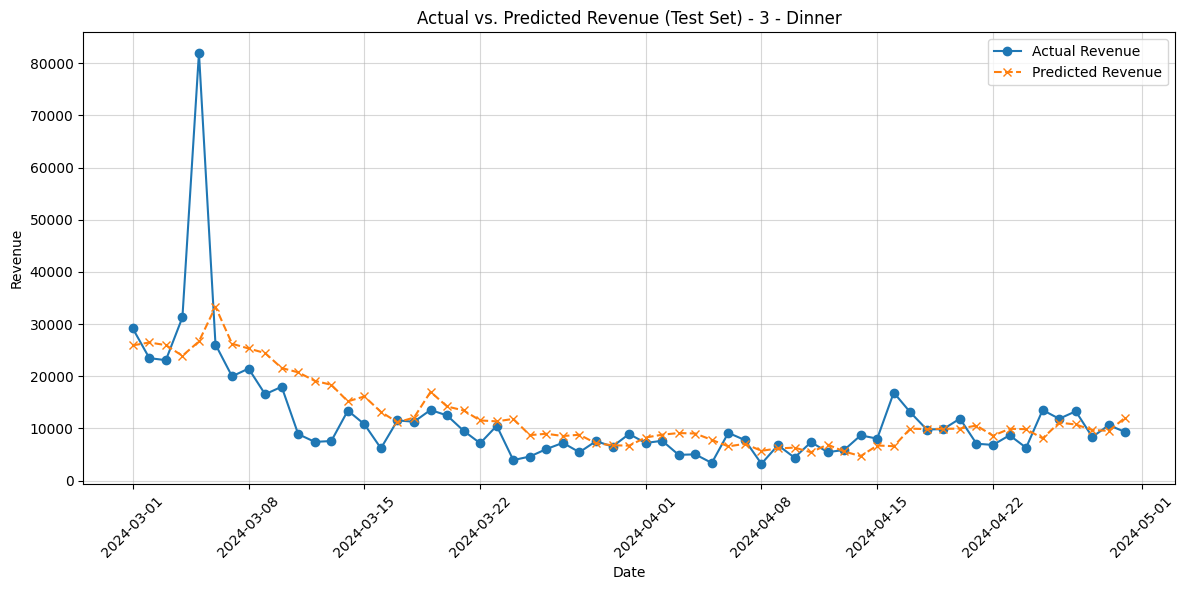

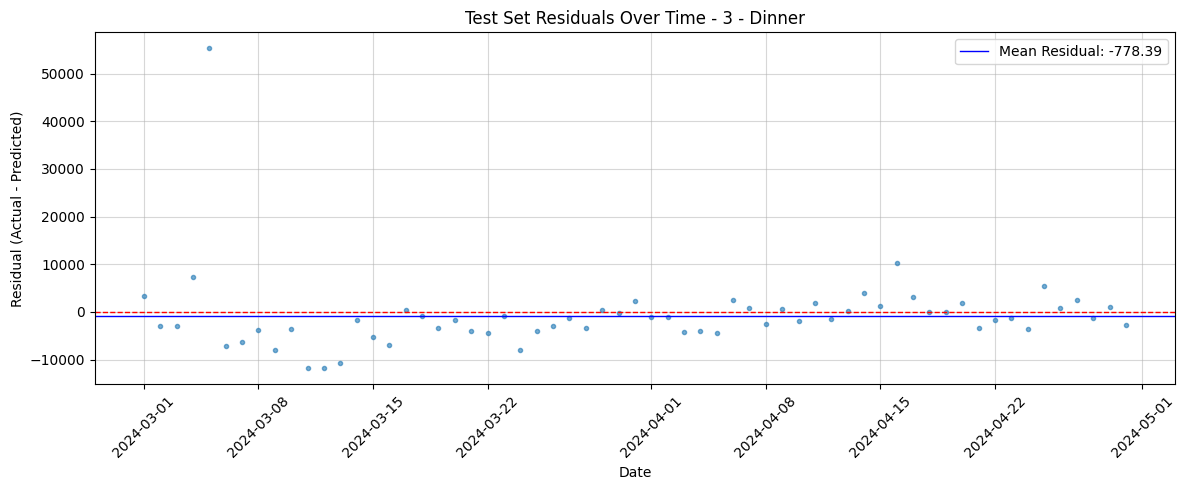


🧠 Starting Optuna Optimization (TPE) for 3 - Lunch
✅ Best parameters found: LR=0.00164, MD=8, Alpha=43.78. Min Avg CV RMSE: 1058.67

--- FINAL TEST SET RESULTS (3 - Lunch) ---
TEST RMSE: 1001.72, TEST MAPE: 47.59%


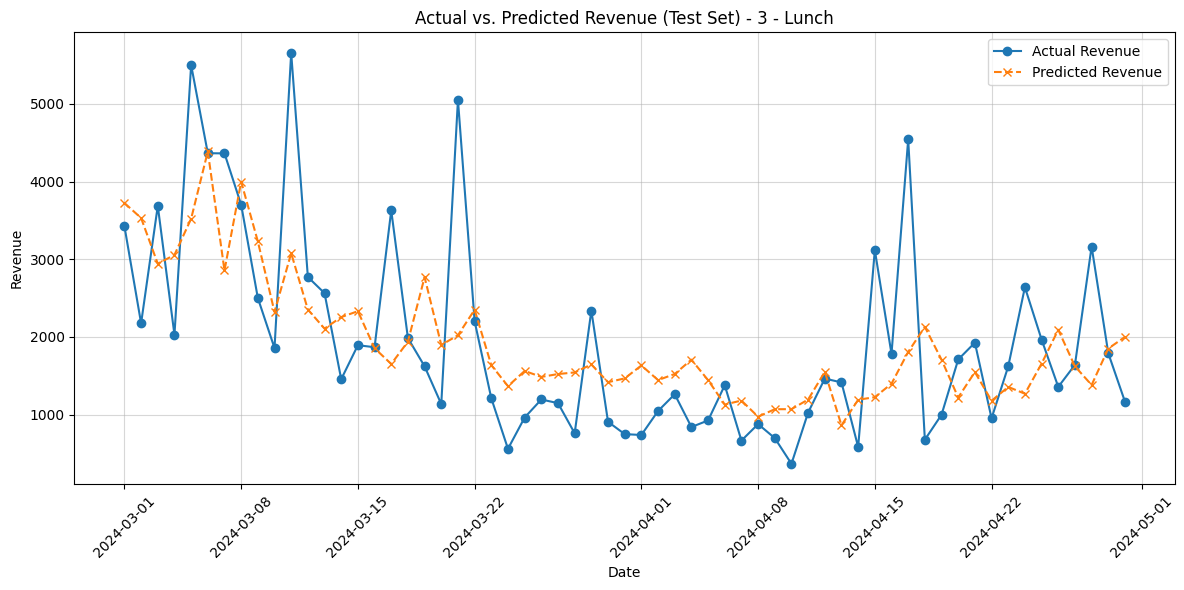

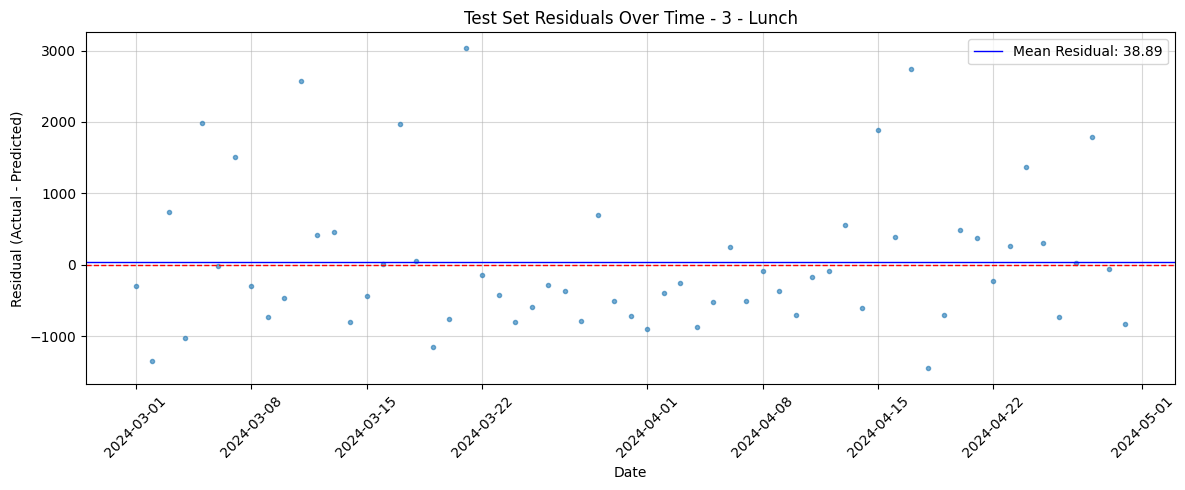


🧠 Starting Optuna Optimization (TPE) for 4 - BreakFast
✅ Best parameters found: LR=0.00307, MD=8, Alpha=27.52. Min Avg CV RMSE: 0.00

--- FINAL TEST SET RESULTS (4 - BreakFast) ---
TEST RMSE: 0.50, TEST MAPE: 50000000.00%


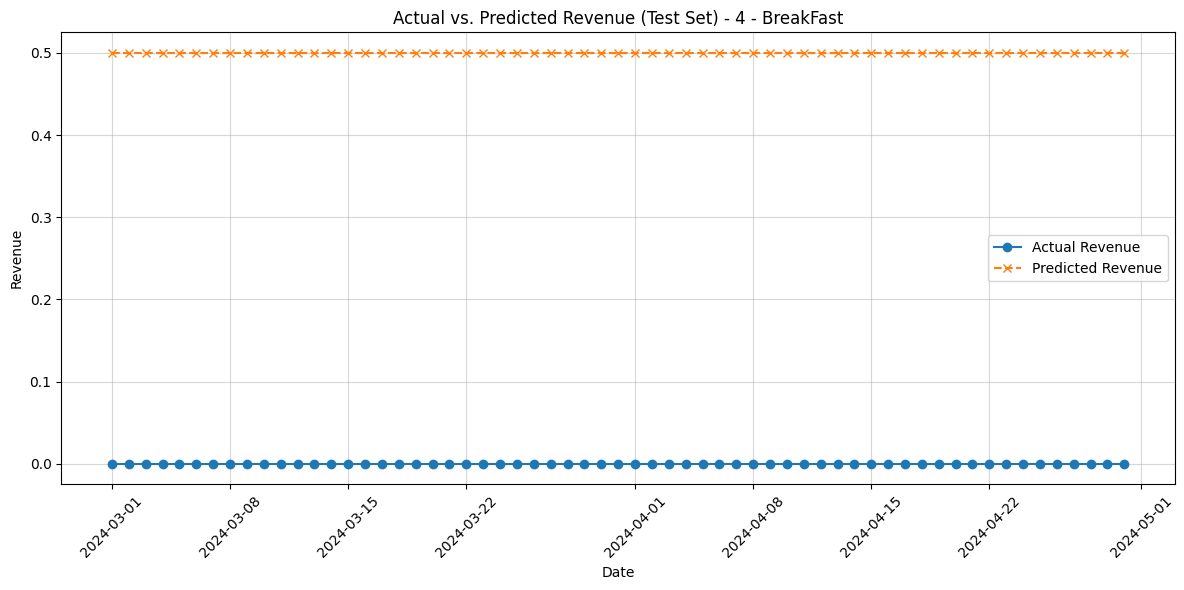

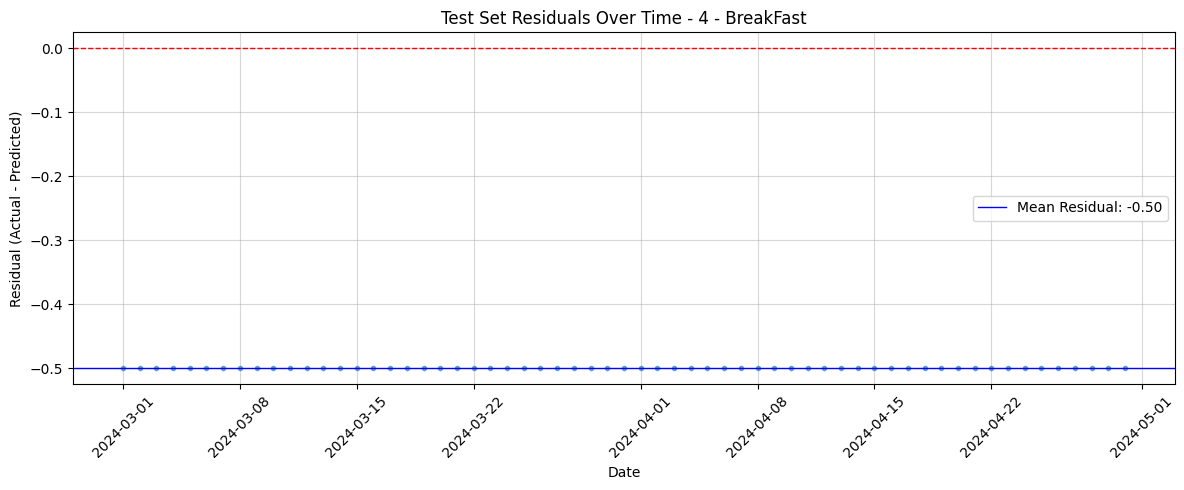


🧠 Starting Optuna Optimization (TPE) for 4 - Dinner
✅ Best parameters found: LR=0.00106, MD=7, Alpha=494.17. Min Avg CV RMSE: 0.00

--- FINAL TEST SET RESULTS (4 - Dinner) ---
TEST RMSE: 0.26, TEST MAPE: 25693741.35%


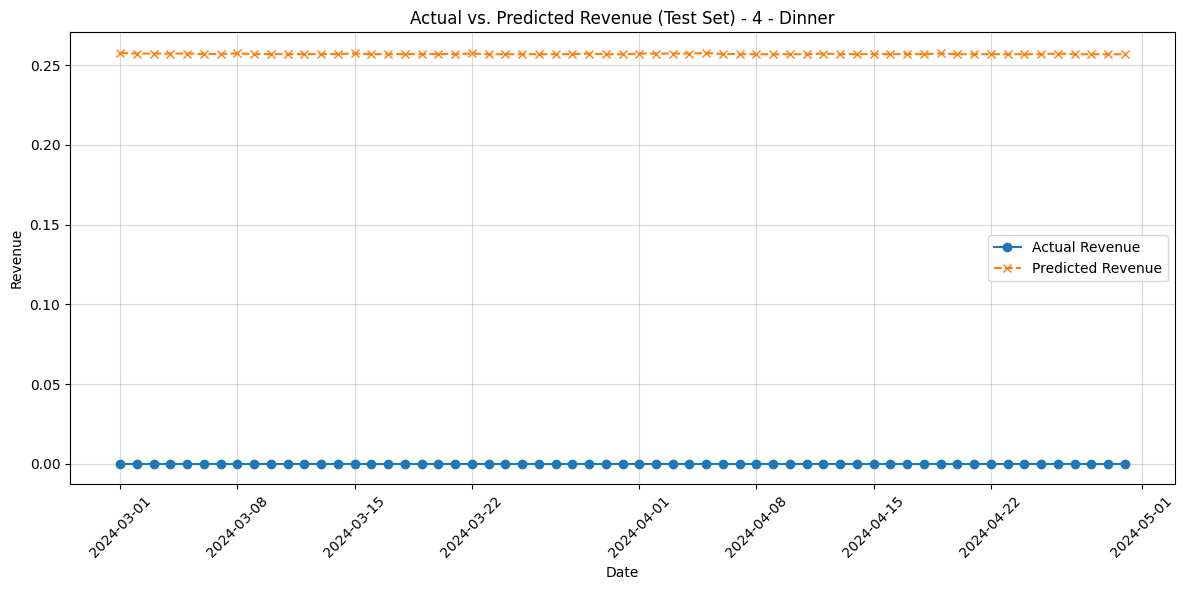

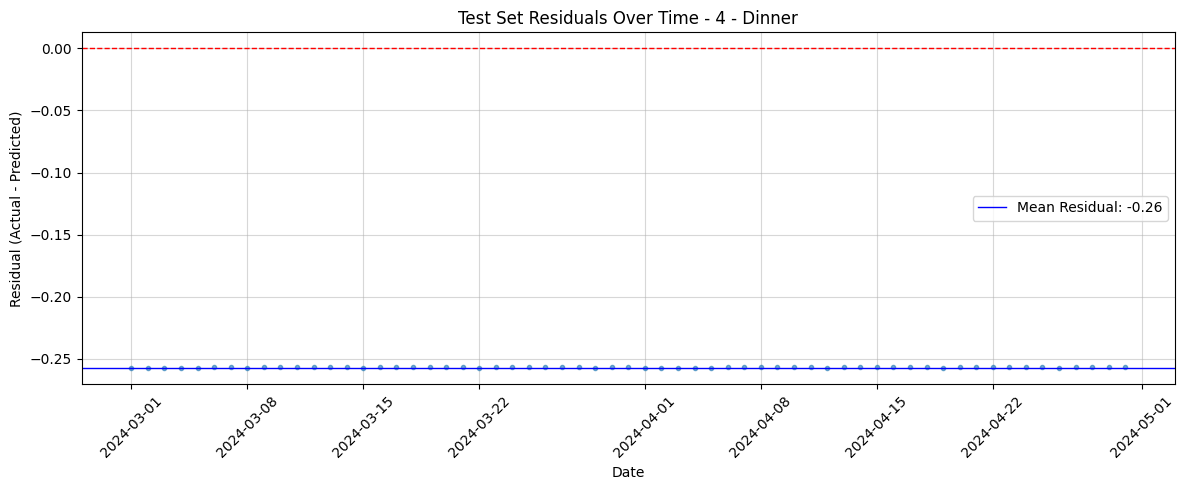


🧠 Starting Optuna Optimization (TPE) for 4 - Lunch
✅ Best parameters found: LR=0.00307, MD=8, Alpha=27.52. Min Avg CV RMSE: 0.00

--- FINAL TEST SET RESULTS (4 - Lunch) ---
TEST RMSE: 0.50, TEST MAPE: 50000000.00%


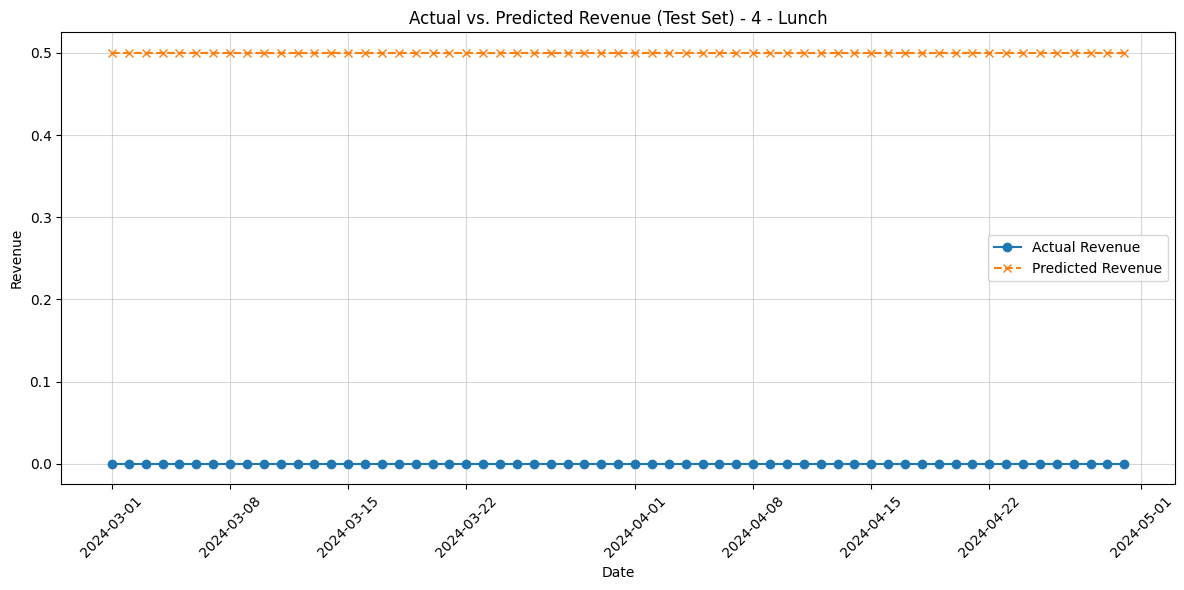

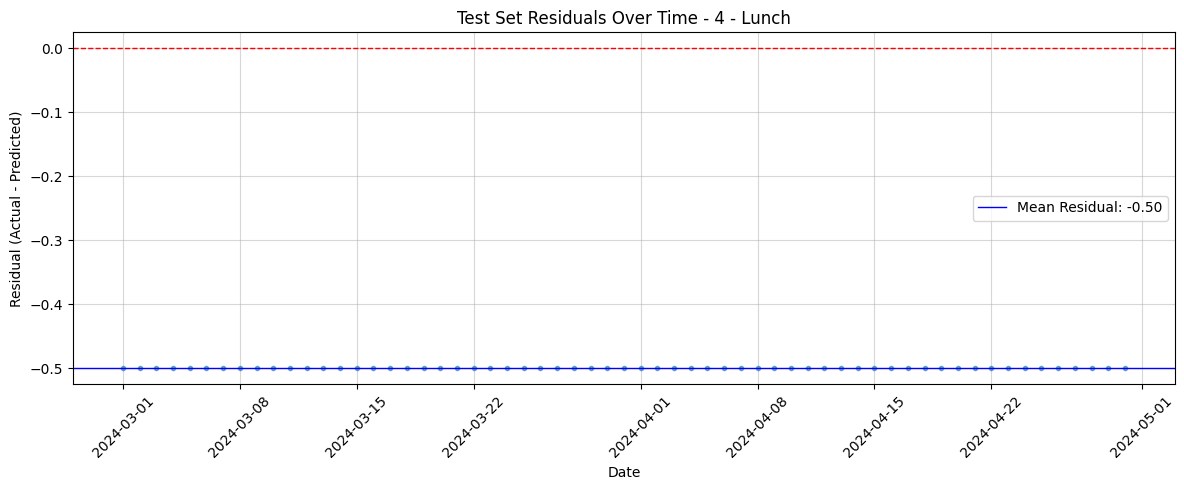


🧠 Starting Optuna Optimization (TPE) for 5 - BreakFast
✅ Best parameters found: LR=0.01095, MD=3, Alpha=0.06. Min Avg CV RMSE: 5158.85

--- FINAL TEST SET RESULTS (5 - BreakFast) ---
TEST RMSE: 2870.37, TEST MAPE: 14.75%


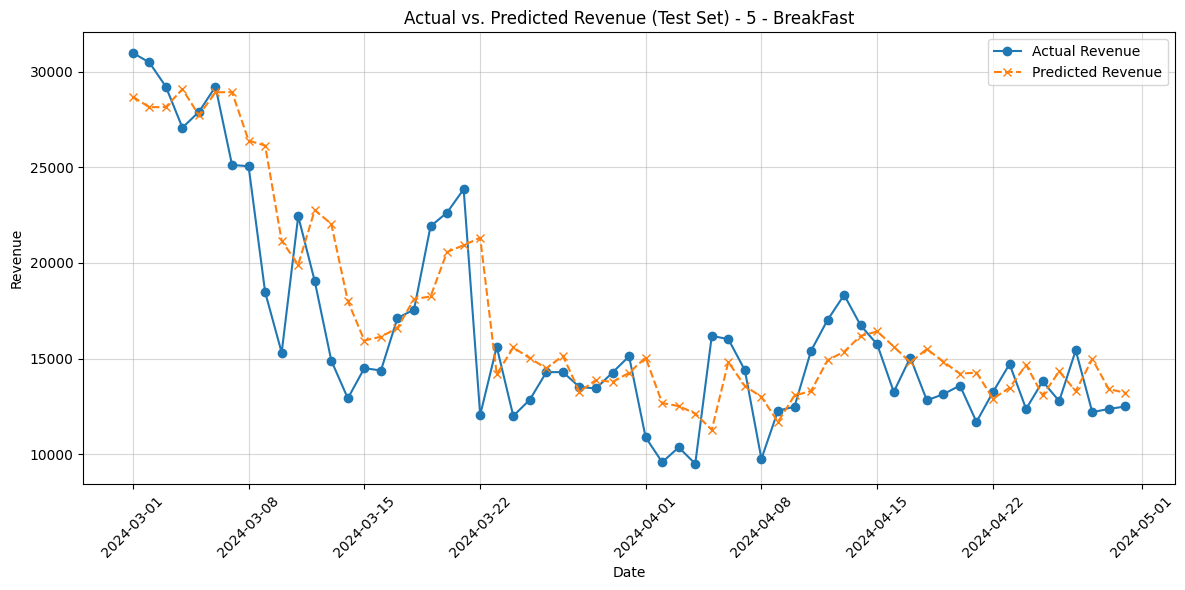

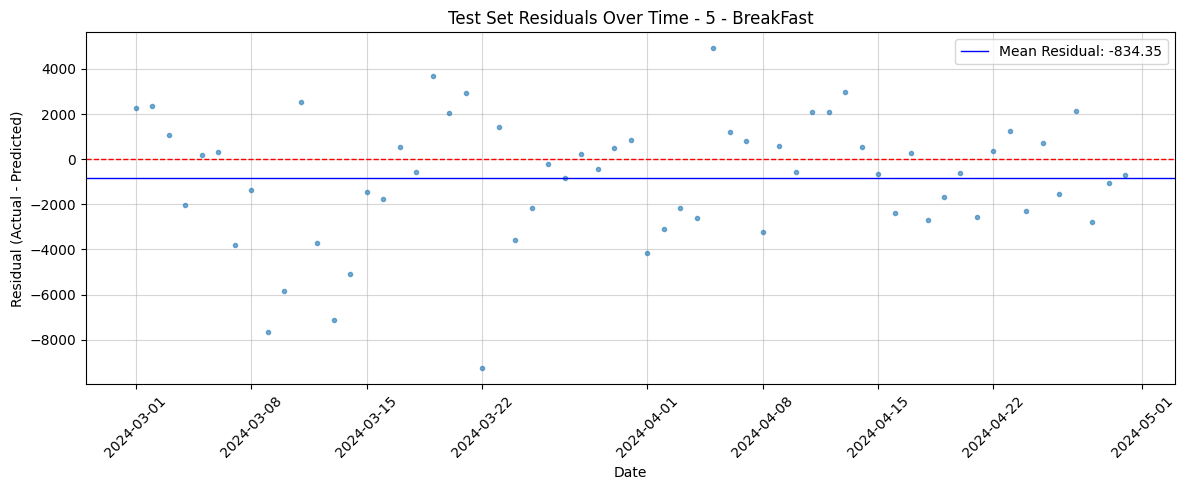


🧠 Starting Optuna Optimization (TPE) for 5 - Dinner
✅ Best parameters found: LR=0.00273, MD=3, Alpha=7.22. Min Avg CV RMSE: 5628.58

--- FINAL TEST SET RESULTS (5 - Dinner) ---
TEST RMSE: 9099.97, TEST MAPE: 53.12%


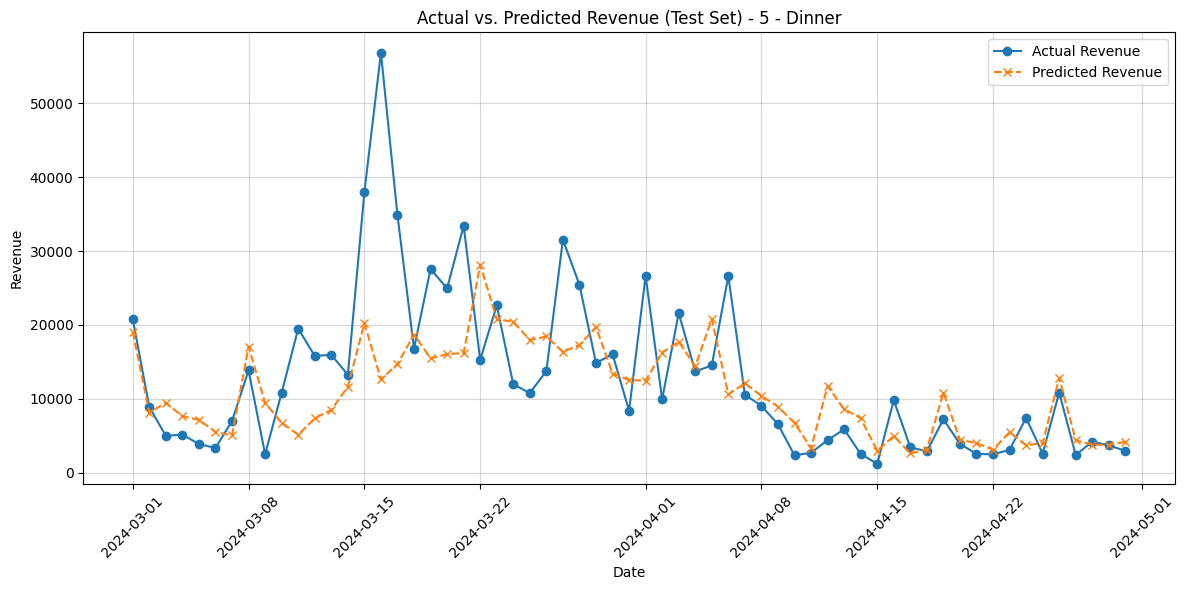

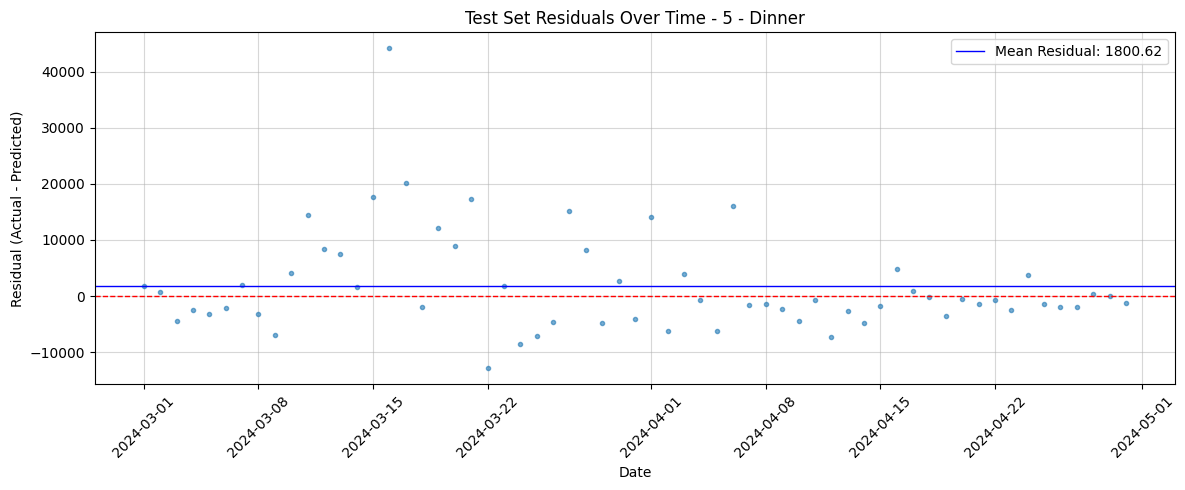


🧠 Starting Optuna Optimization (TPE) for 5 - Lunch
✅ Best parameters found: LR=0.00143, MD=8, Alpha=170.18. Min Avg CV RMSE: 2783.36

--- FINAL TEST SET RESULTS (5 - Lunch) ---
TEST RMSE: 3576.40, TEST MAPE: 9961710017.17%


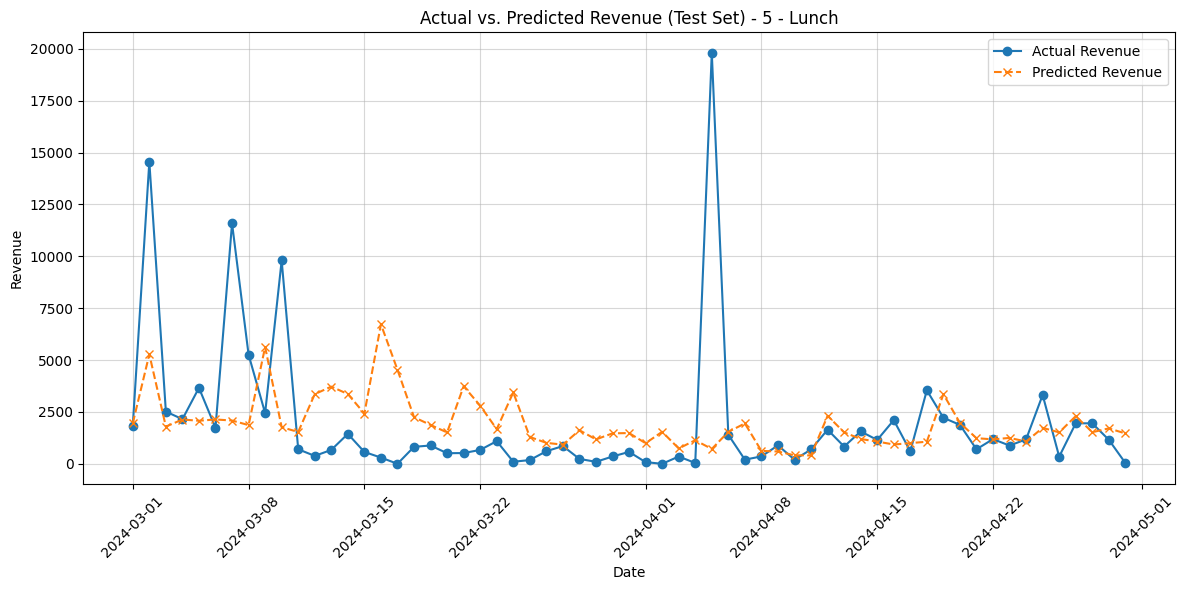

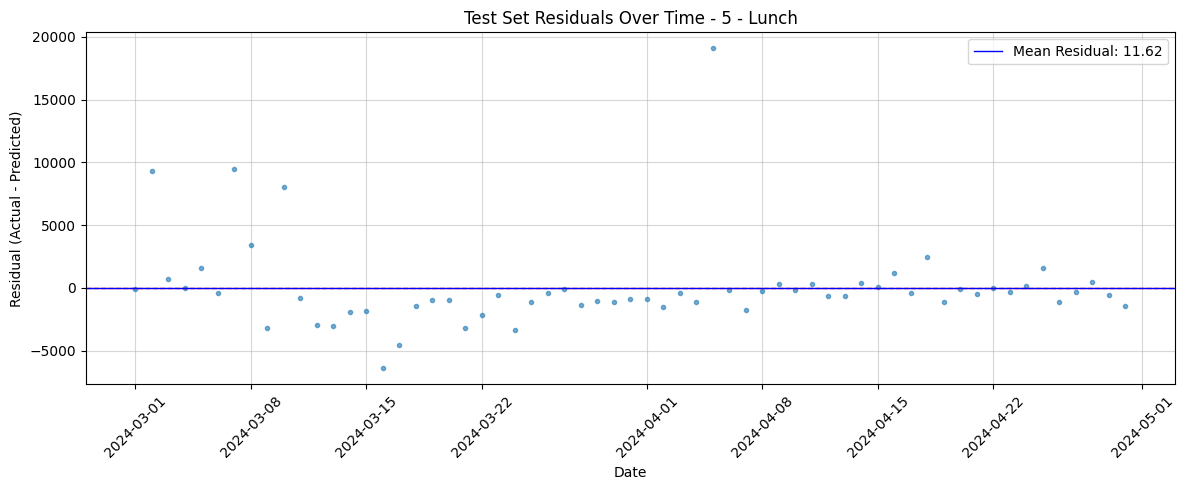


🧠 Starting Optuna Optimization (TPE) for 6 - BreakFast
✅ Best parameters found: LR=0.00237, MD=3, Alpha=467.78. Min Avg CV RMSE: 282.57

--- FINAL TEST SET RESULTS (6 - BreakFast) ---
TEST RMSE: 435.09, TEST MAPE: 8117893129.18%


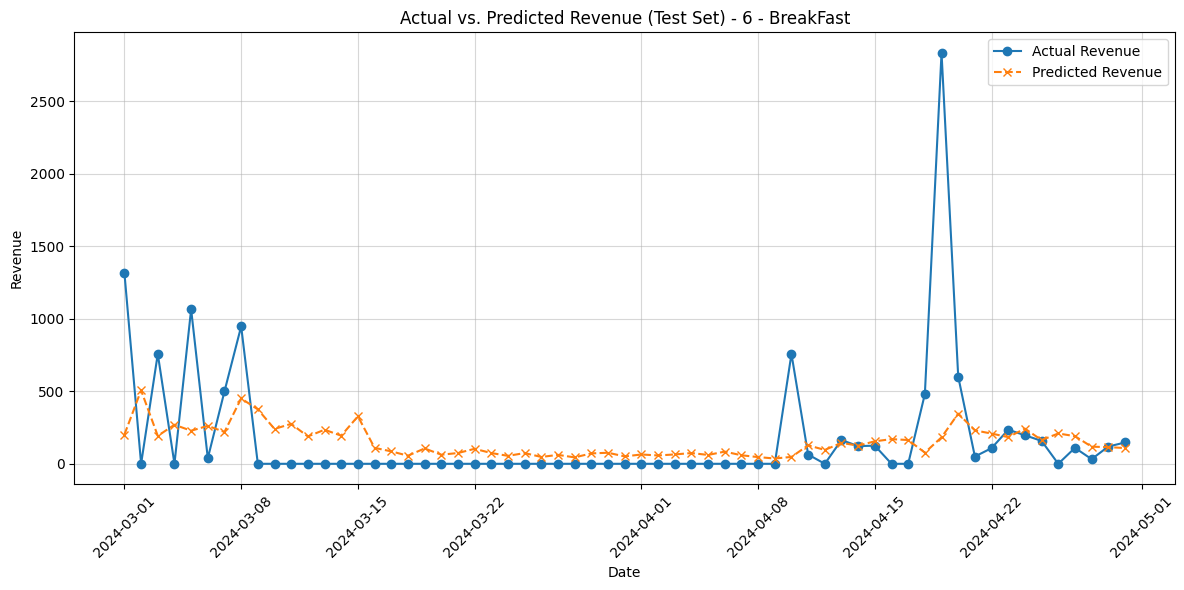

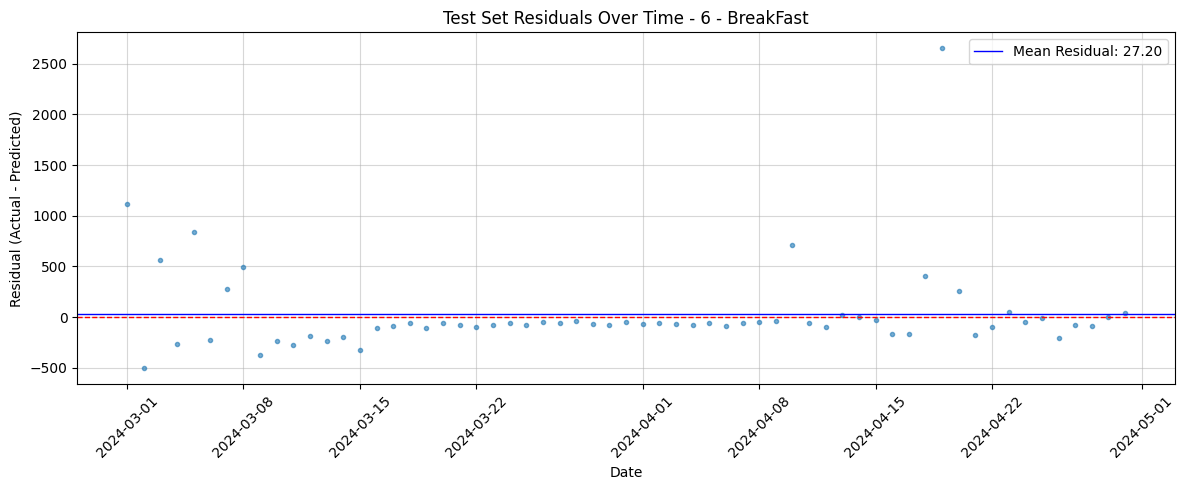


🧠 Starting Optuna Optimization (TPE) for 6 - Dinner
✅ Best parameters found: LR=0.00124, MD=5, Alpha=153.93. Min Avg CV RMSE: 2781.90

--- FINAL TEST SET RESULTS (6 - Dinner) ---
TEST RMSE: 7055.08, TEST MAPE: 6574348336.55%


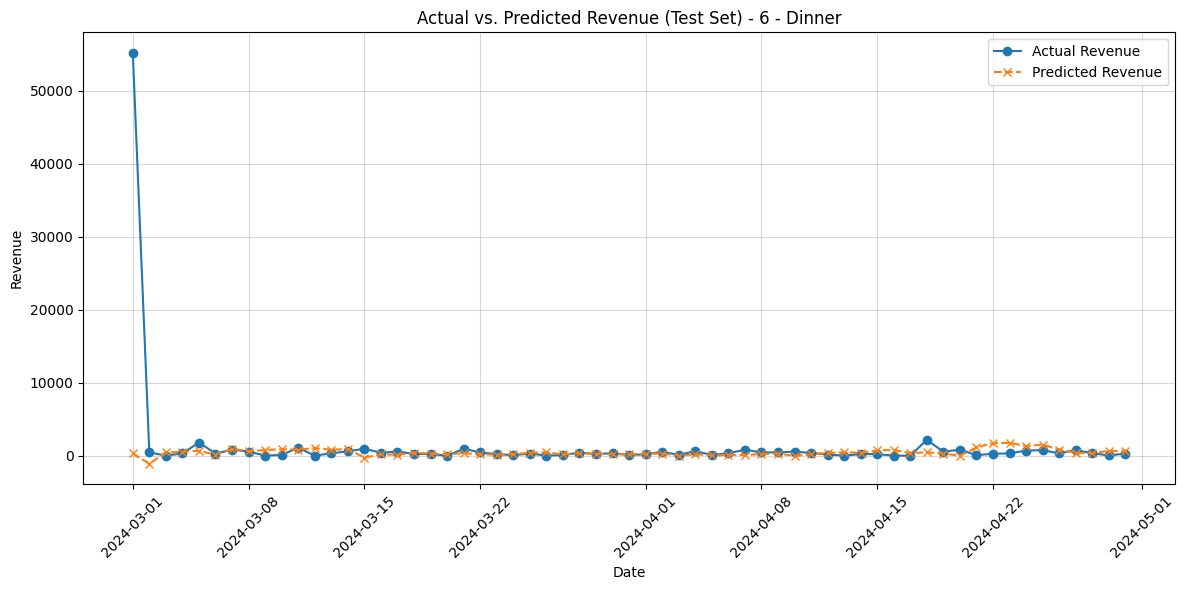

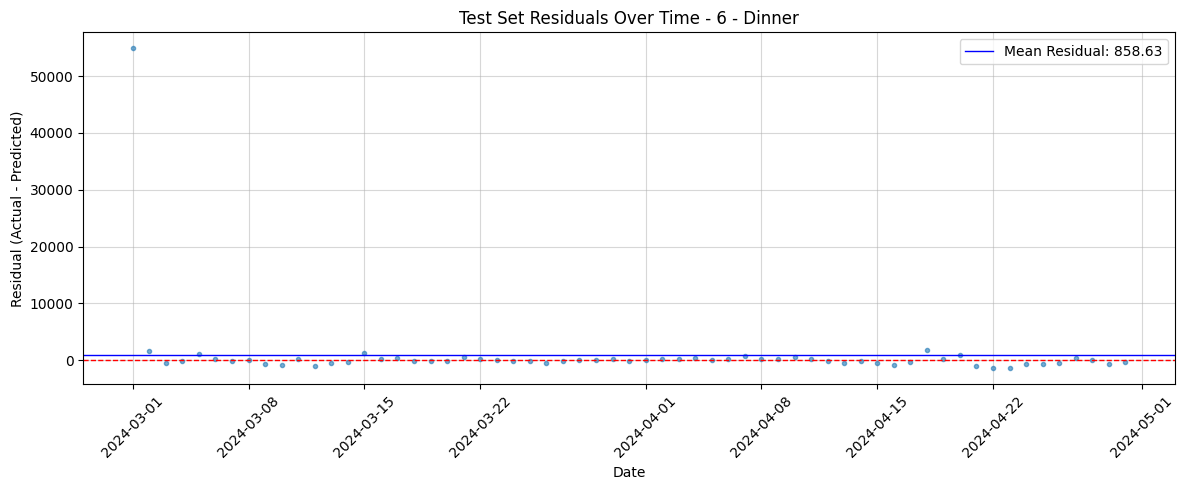


🧠 Starting Optuna Optimization (TPE) for 6 - Lunch
✅ Best parameters found: LR=0.00208, MD=3, Alpha=281.42. Min Avg CV RMSE: 524.67

--- FINAL TEST SET RESULTS (6 - Lunch) ---
TEST RMSE: 706.58, TEST MAPE: 19834170244.29%


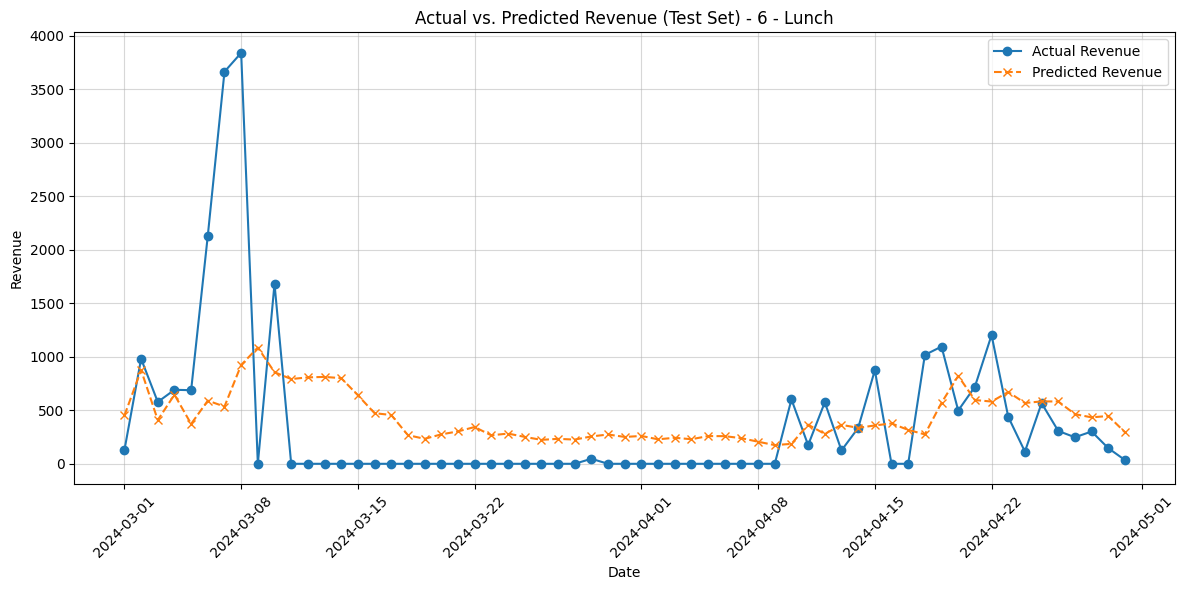

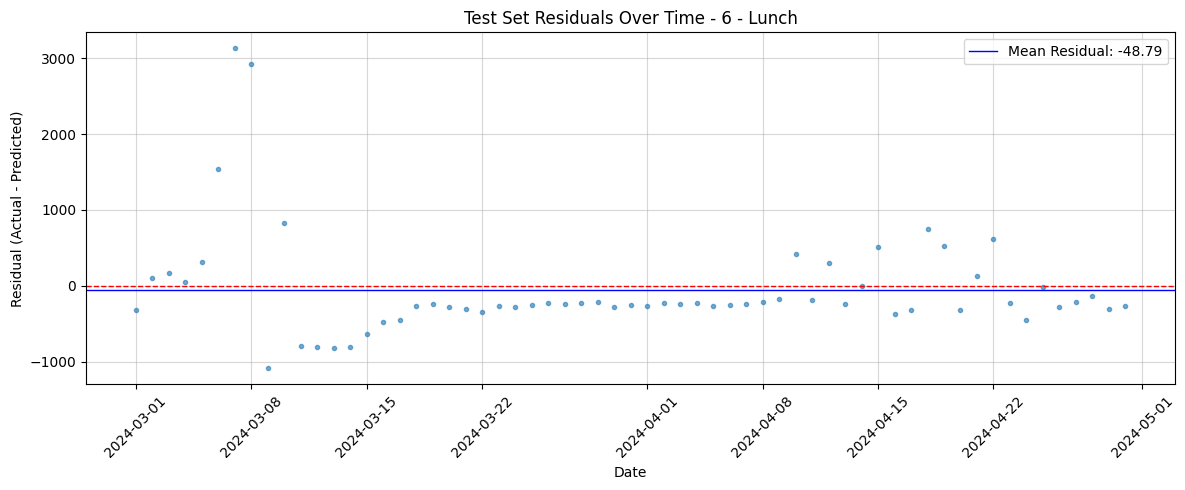


🧠 Starting Optuna Optimization (TPE) for 7 - BreakFast
✅ Best parameters found: LR=0.00102, MD=8, Alpha=452.82. Min Avg CV RMSE: 63.54

--- FINAL TEST SET RESULTS (7 - BreakFast) ---
TEST RMSE: 41.54, TEST MAPE: 2427759256.88%


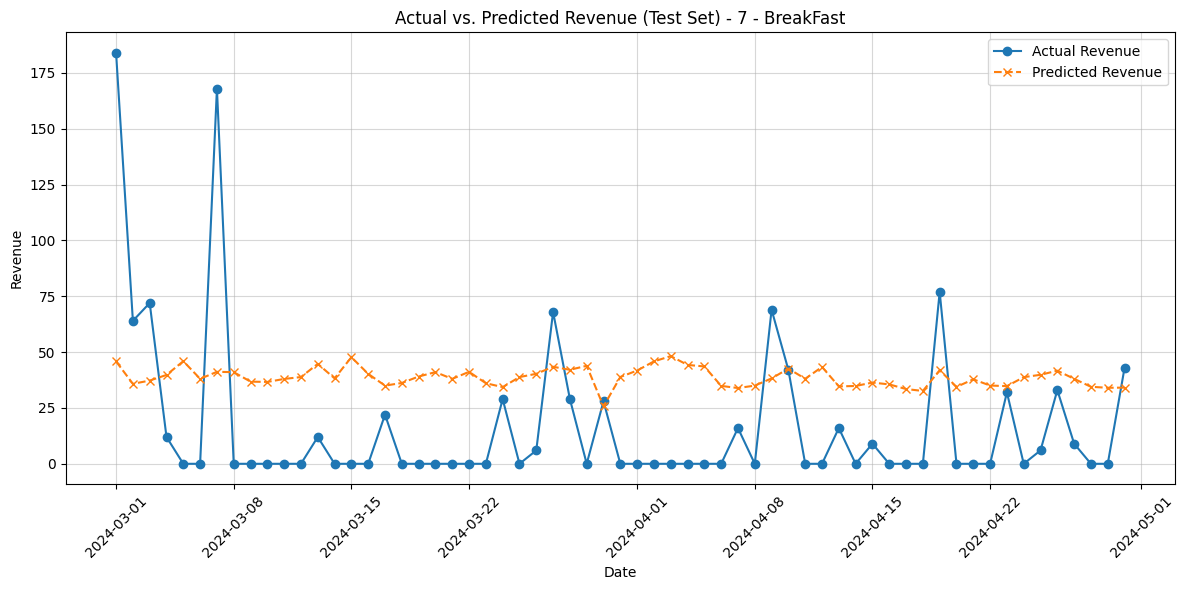

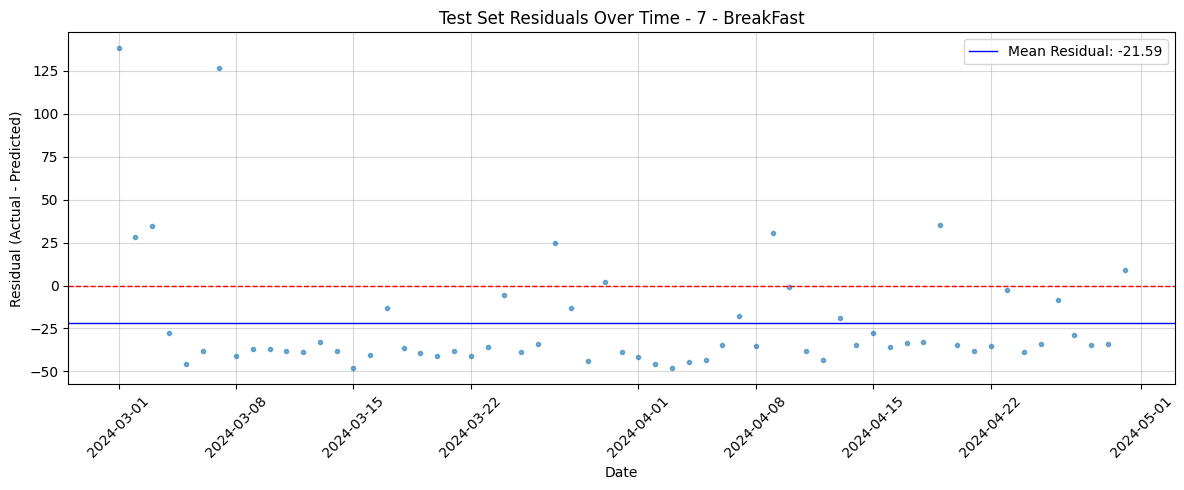


🧠 Starting Optuna Optimization (TPE) for 7 - Dinner
✅ Best parameters found: LR=0.00117, MD=8, Alpha=0.02. Min Avg CV RMSE: 79.70

--- FINAL TEST SET RESULTS (7 - Dinner) ---
TEST RMSE: 128.66, TEST MAPE: 1242369643.81%


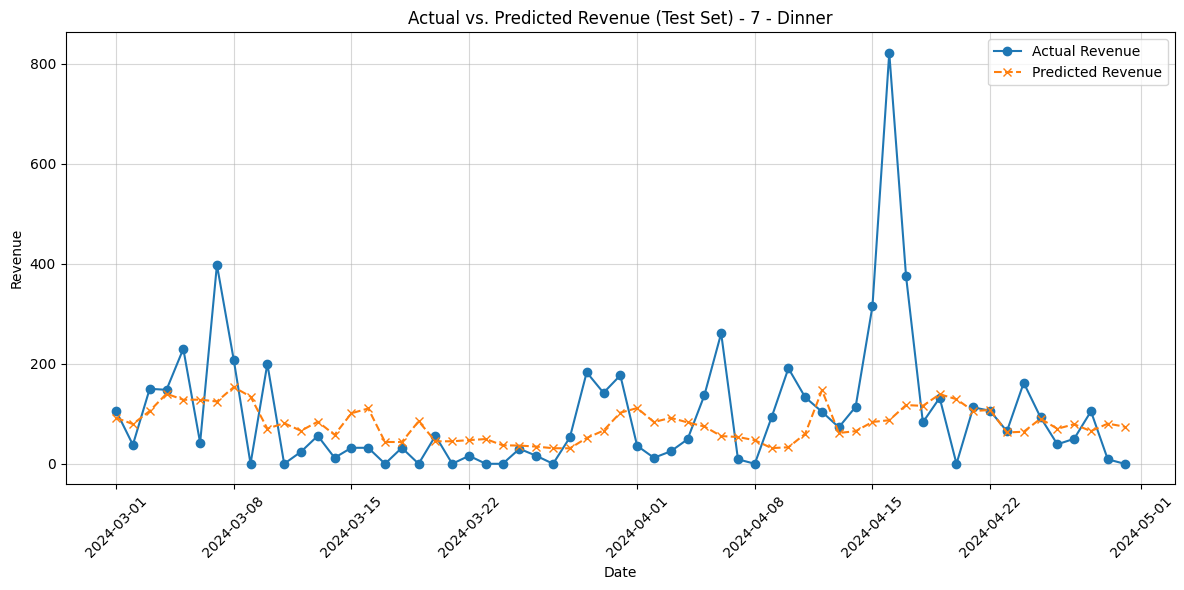

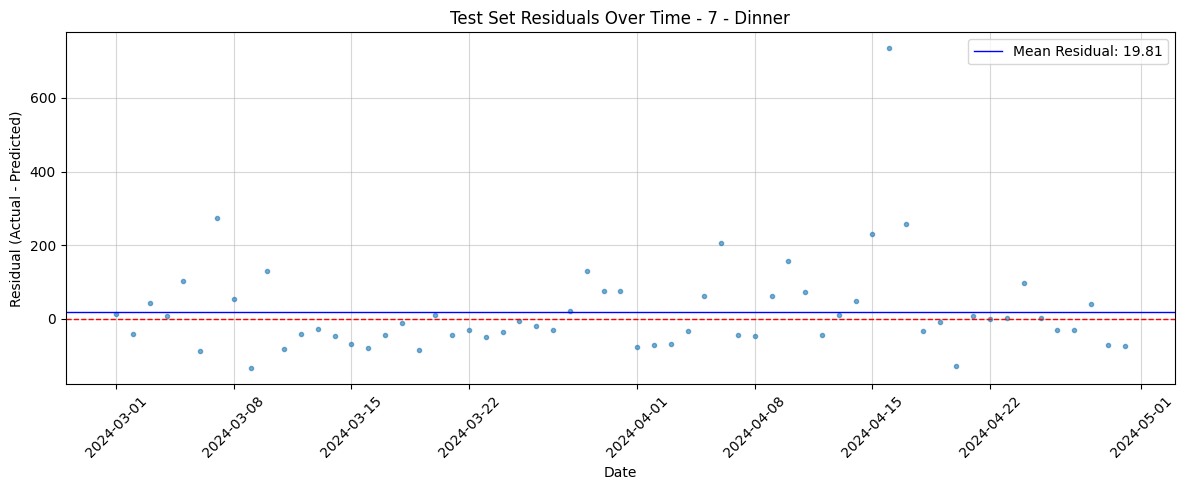


🧠 Starting Optuna Optimization (TPE) for 7 - Lunch
✅ Best parameters found: LR=0.00246, MD=5, Alpha=494.99. Min Avg CV RMSE: 49.91

--- FINAL TEST SET RESULTS (7 - Lunch) ---
TEST RMSE: 68.35, TEST MAPE: 1959482735.97%


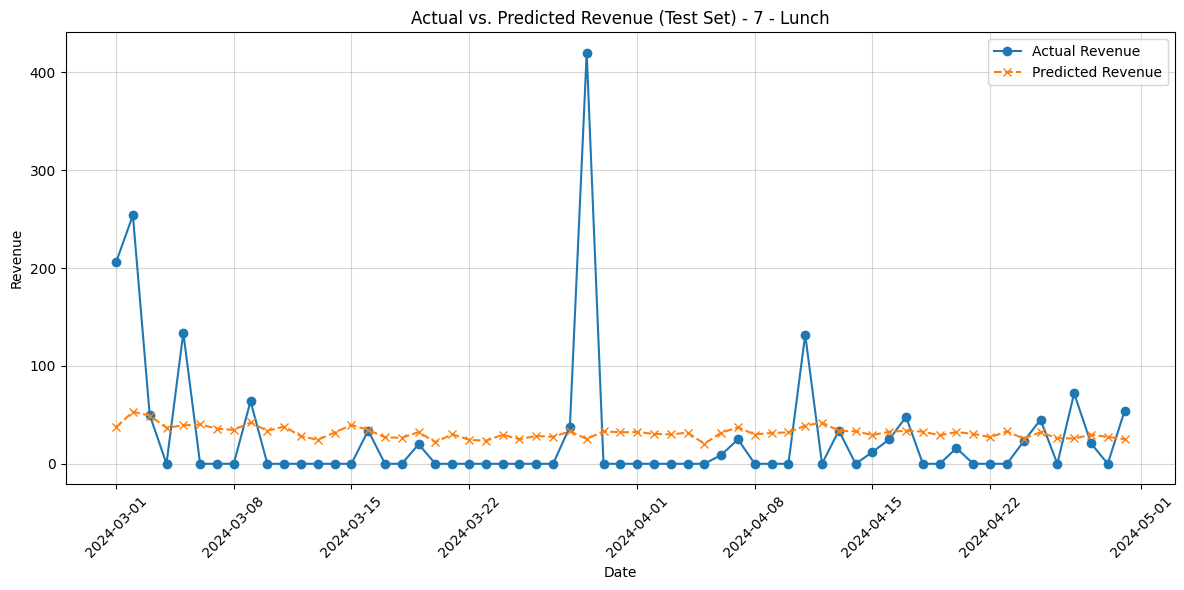

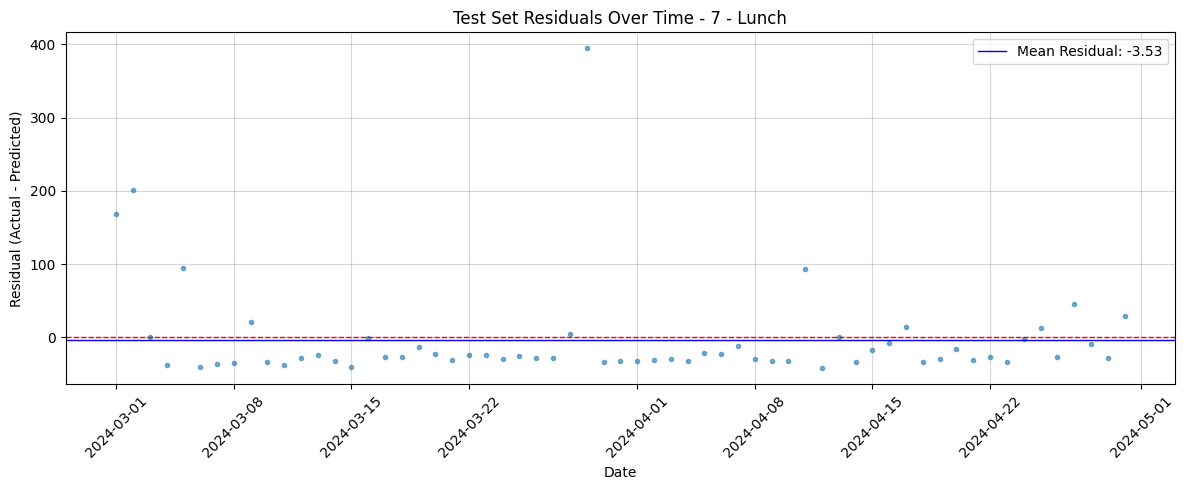


🧠 Starting Optuna Optimization (TPE) for 8 - BreakFast
✅ Best parameters found: LR=0.00132, MD=4, Alpha=464.63. Min Avg CV RMSE: 2511.85

--- FINAL TEST SET RESULTS (8 - BreakFast) ---
TEST RMSE: 3751.78, TEST MAPE: 46069435121.69%


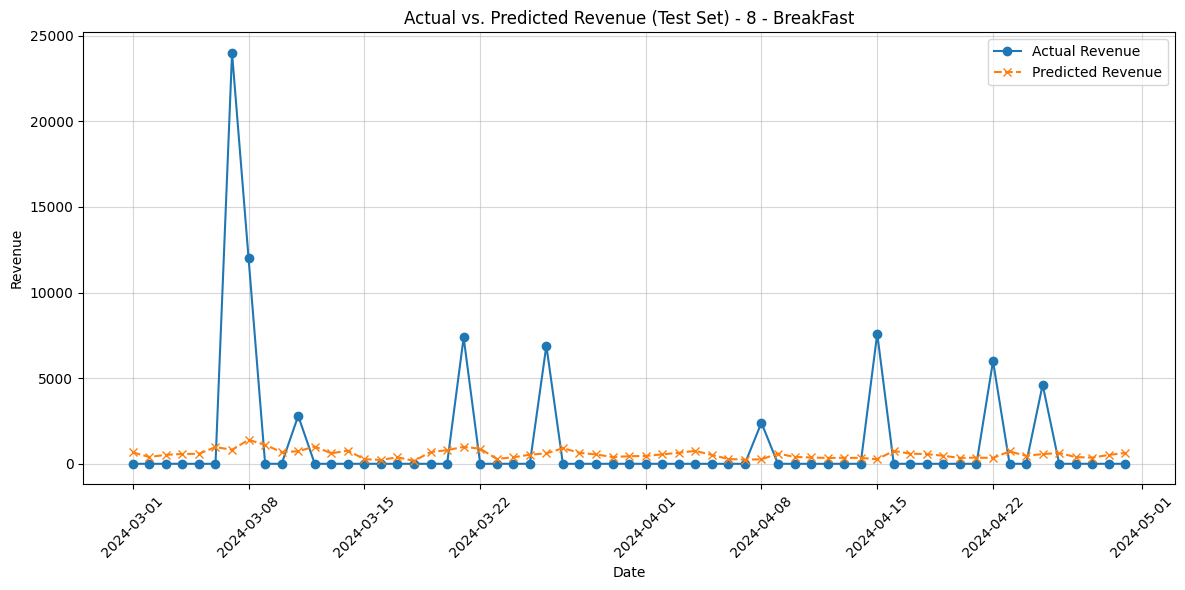

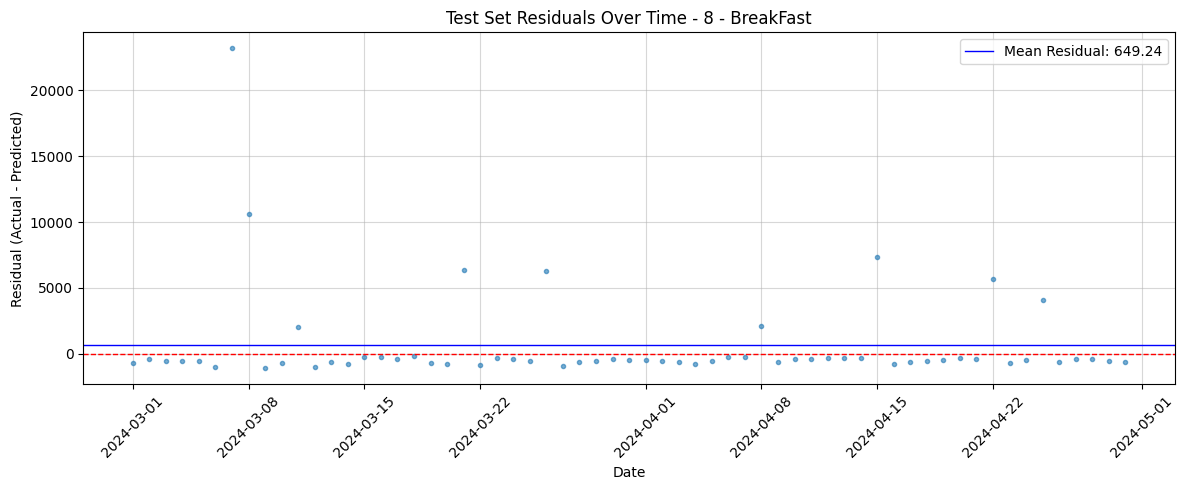


🧠 Starting Optuna Optimization (TPE) for 8 - Dinner
✅ Best parameters found: LR=0.00629, MD=8, Alpha=215.82. Min Avg CV RMSE: 18000.32

--- FINAL TEST SET RESULTS (8 - Dinner) ---
TEST RMSE: 23093.80, TEST MAPE: 519208979282.66%


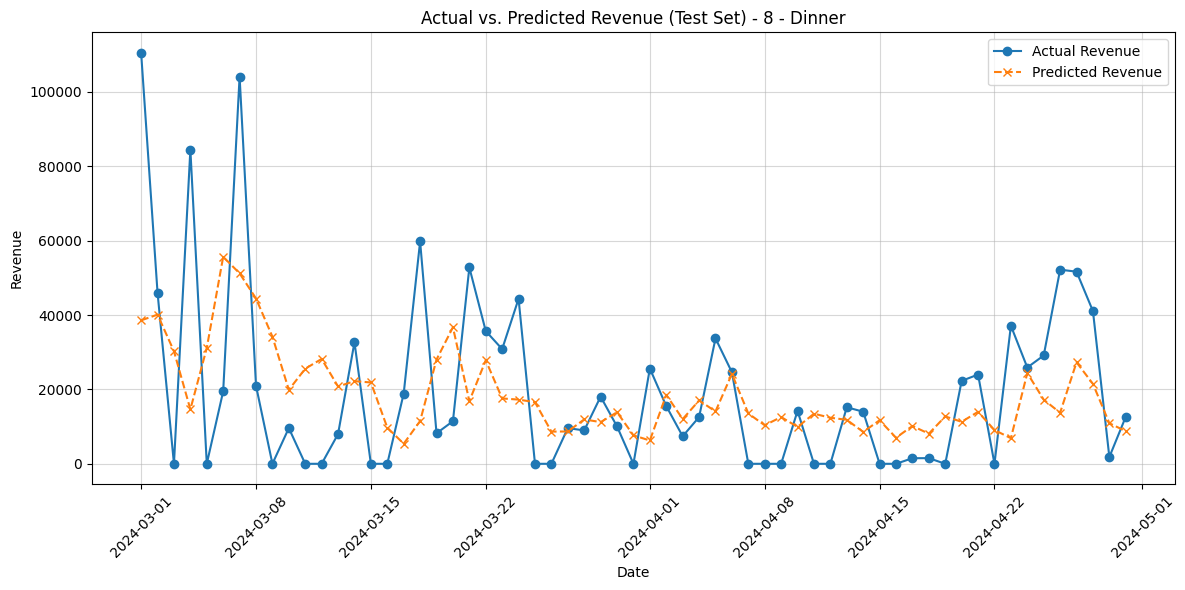

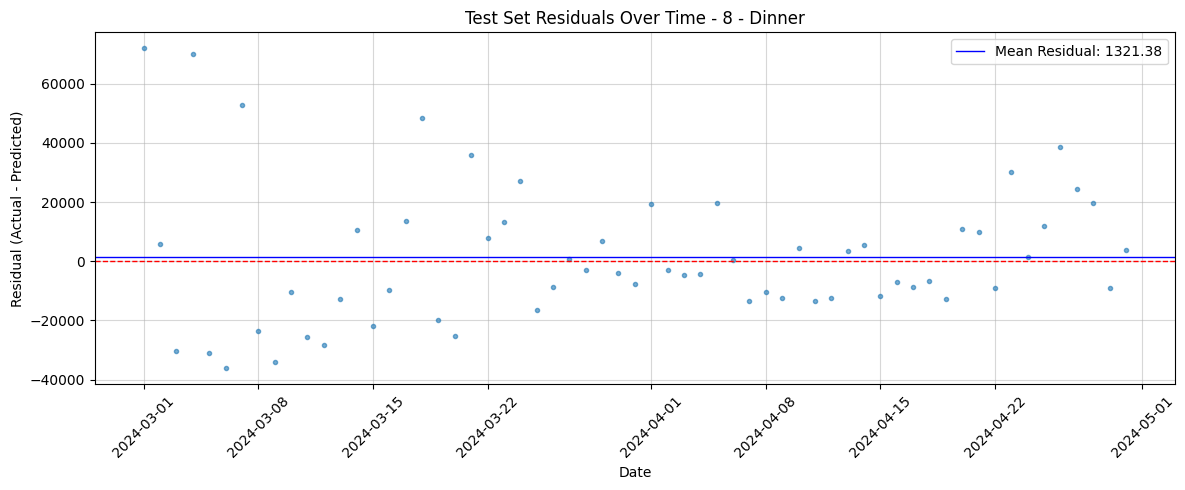


🧠 Starting Optuna Optimization (TPE) for 8 - Lunch
✅ Best parameters found: LR=0.00196, MD=8, Alpha=20.92. Min Avg CV RMSE: 14229.77

--- FINAL TEST SET RESULTS (8 - Lunch) ---
TEST RMSE: 16179.55, TEST MAPE: 354581682808.32%


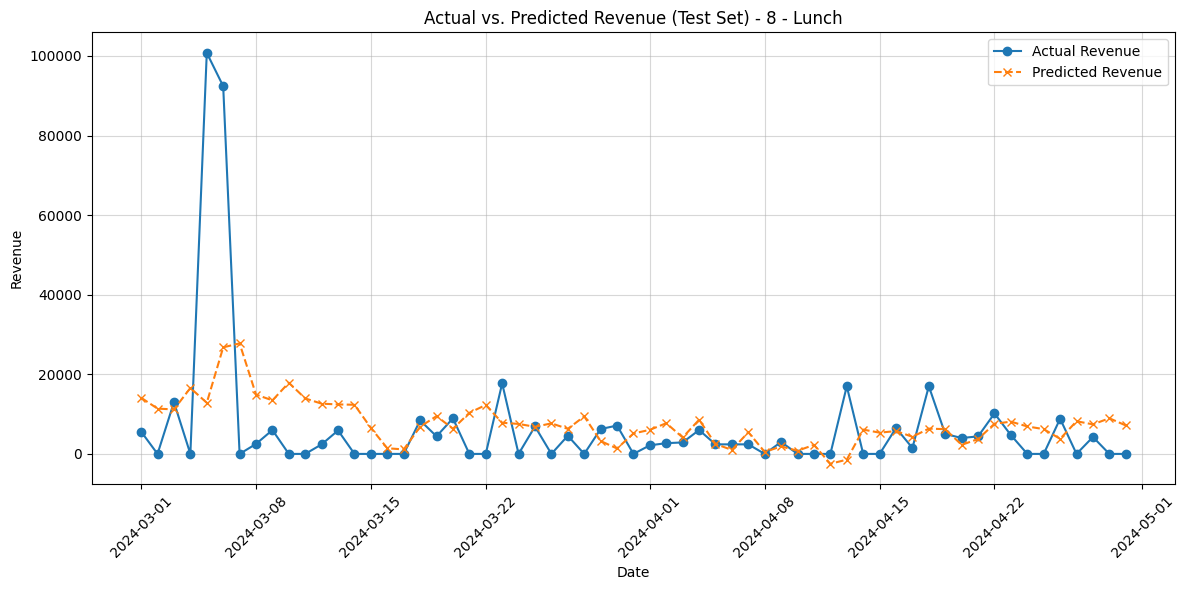

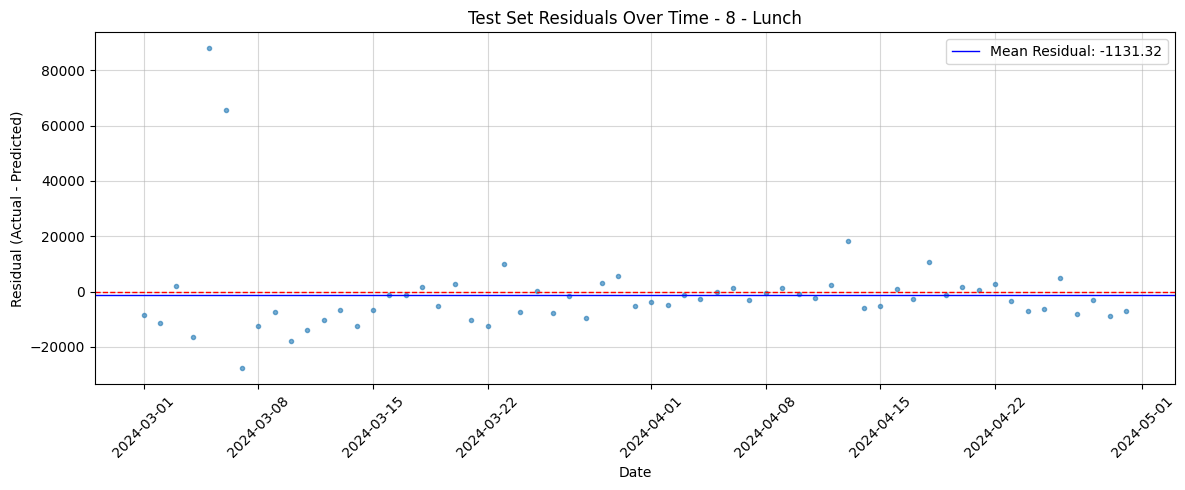


🧠 Starting Optuna Optimization (TPE) for 9 - BreakFast
✅ Best parameters found: LR=0.00888, MD=3, Alpha=0.08. Min Avg CV RMSE: 230.03

--- FINAL TEST SET RESULTS (9 - BreakFast) ---
TEST RMSE: 305.77, TEST MAPE: 2572172055.15%


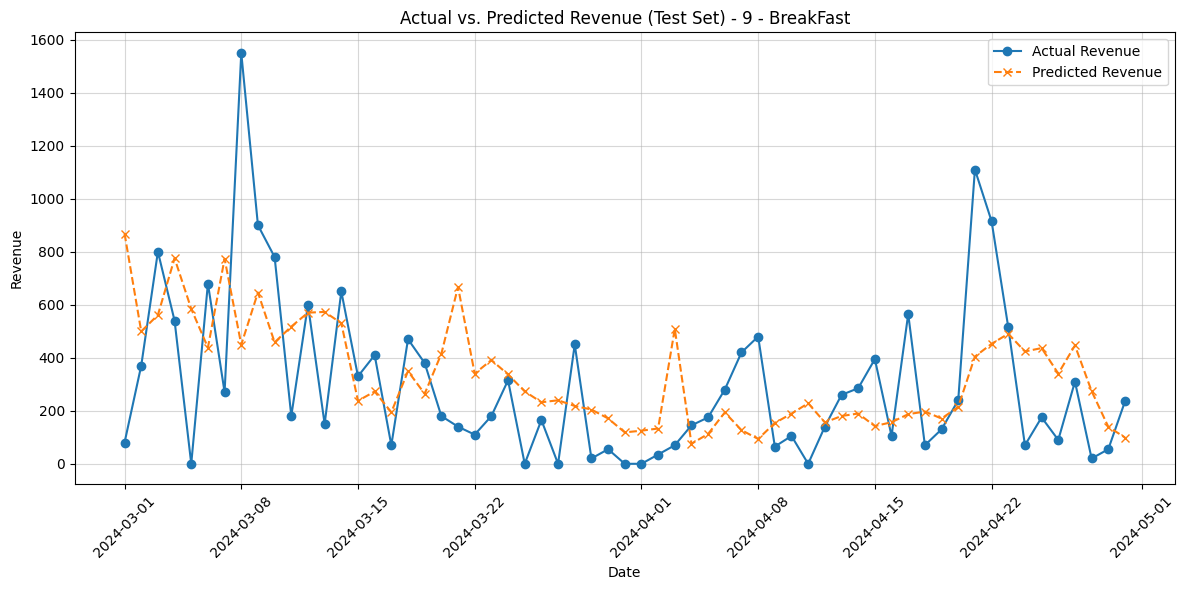

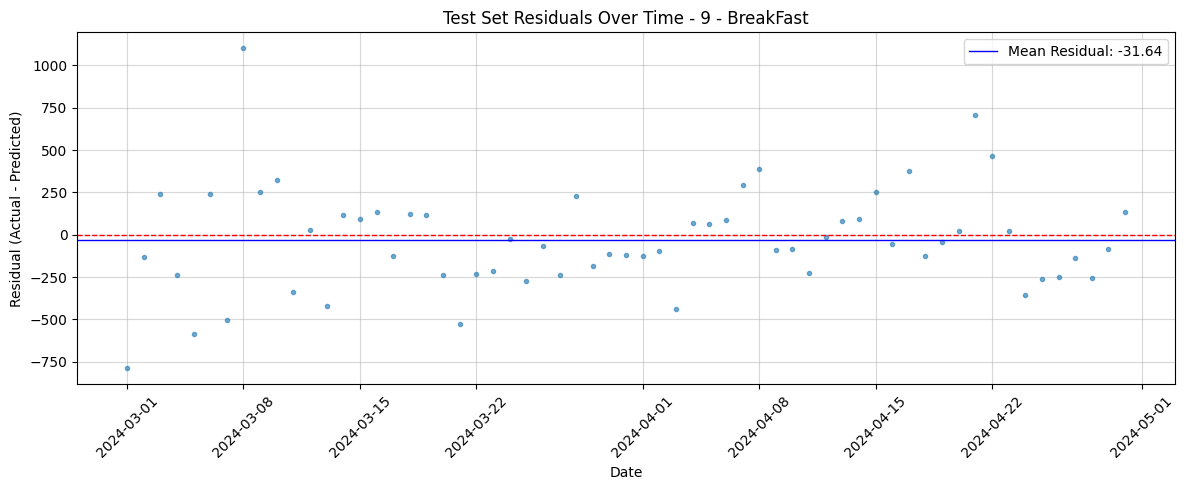


🧠 Starting Optuna Optimization (TPE) for 9 - Dinner
✅ Best parameters found: LR=0.00106, MD=8, Alpha=102.43. Min Avg CV RMSE: 87.71

--- FINAL TEST SET RESULTS (9 - Dinner) ---
TEST RMSE: 181.59, TEST MAPE: 3555792521.61%


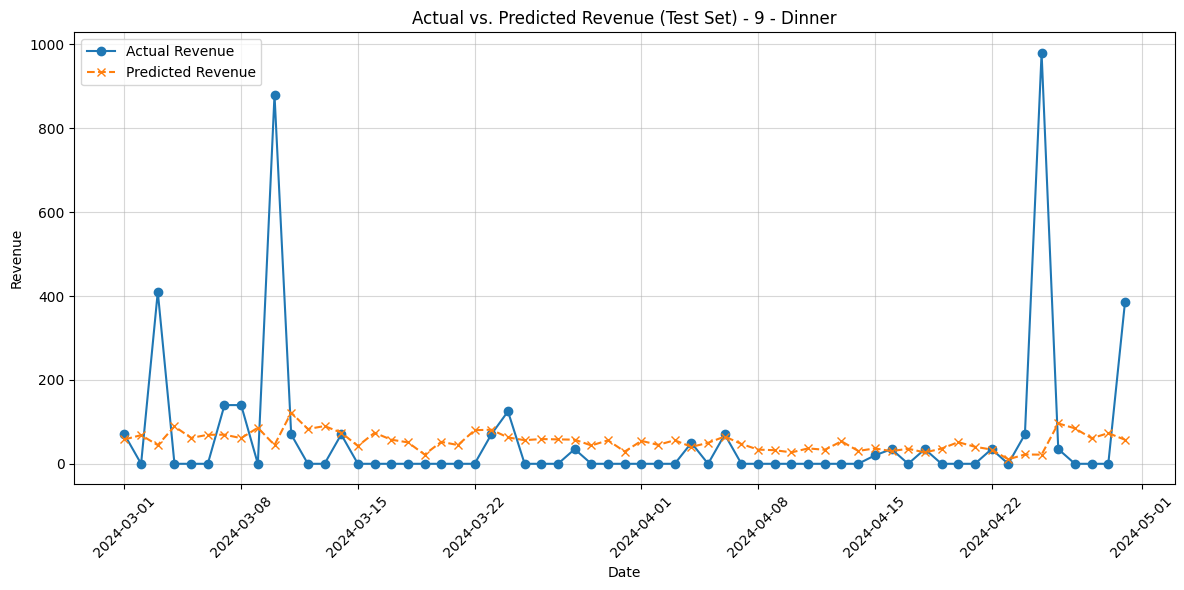

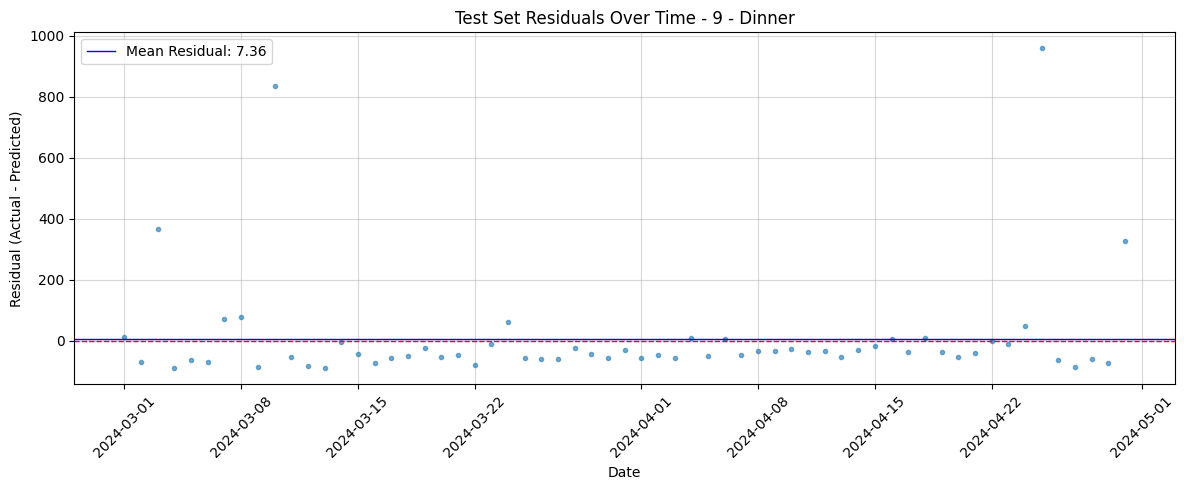


🧠 Starting Optuna Optimization (TPE) for 9 - Lunch
✅ Best parameters found: LR=0.00122, MD=8, Alpha=235.22. Min Avg CV RMSE: 194.47

--- FINAL TEST SET RESULTS (9 - Lunch) ---
TEST RMSE: 218.01, TEST MAPE: 4058033919.29%


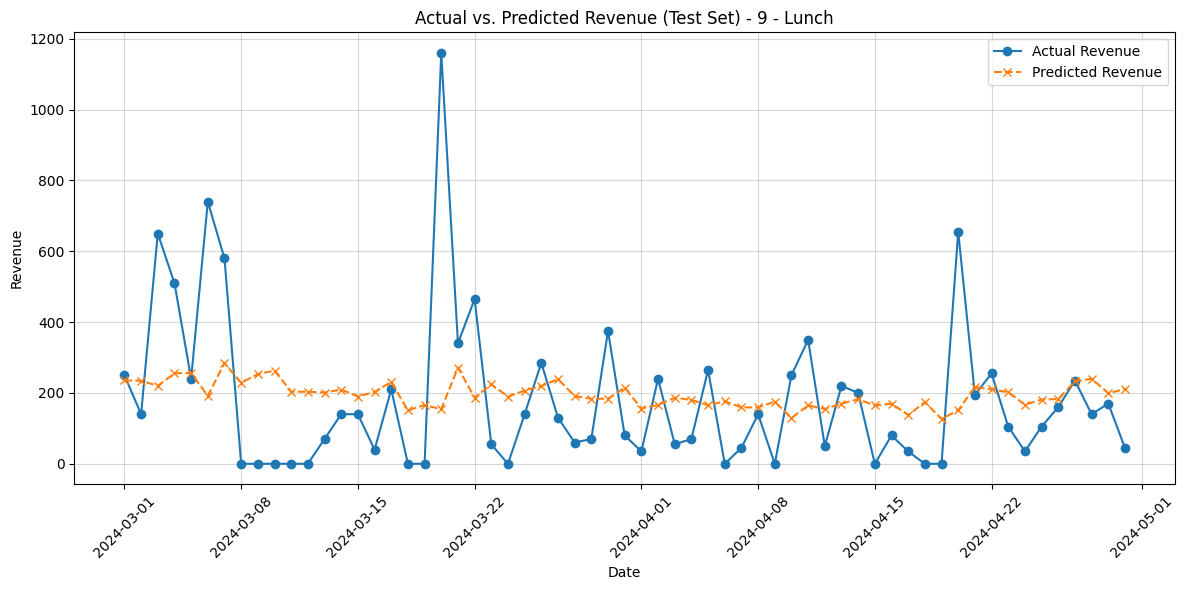

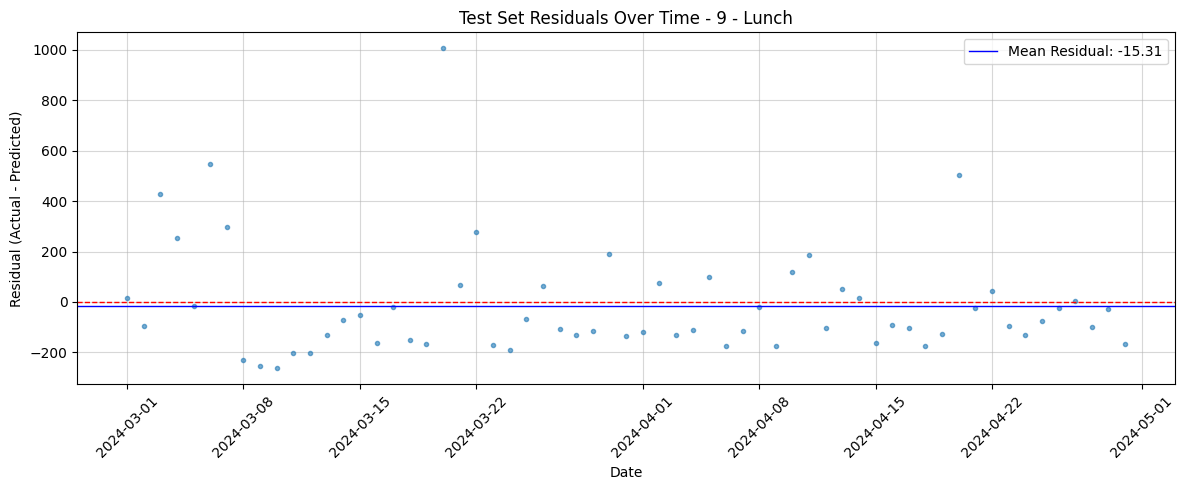



🥇 FINAL HYPERPARAMETER COMPARISON TABLE (Optuna TPE)
|   Center | Meal      | Method     |   Best_LR |   Best_MD |   Best_Alpha |   Avg_CV_RMSE |
|---------:|:----------|:-----------|----------:|----------:|-------------:|--------------:|
|        1 | BreakFast | Optuna TPE |   0.00746 |         3 |         0.06 |        882.1  |
|        1 | Dinner    | Optuna TPE |   0.01633 |         3 |         0.02 |       1471.74 |
|        1 | Lunch     | Optuna TPE |   0.00189 |         8 |         0.24 |        767.26 |
|        2 | BreakFast | Optuna TPE |   0.00932 |         5 |       415.04 |        349.76 |
|        2 | Dinner    | Optuna TPE |   0.00586 |         8 |        10.7  |        868.76 |
|        2 | Lunch     | Optuna TPE |   0.01633 |         3 |         0.02 |        420.44 |
|        3 | BreakFast | Optuna TPE |   0.01319 |         3 |       490    |        366.02 |
|        3 | Dinner    | Optuna TPE |   0.01478 |         5 |         0.01 |       4280.25 |
|        3 | Lu

<Figure size 1400x700 with 0 Axes>

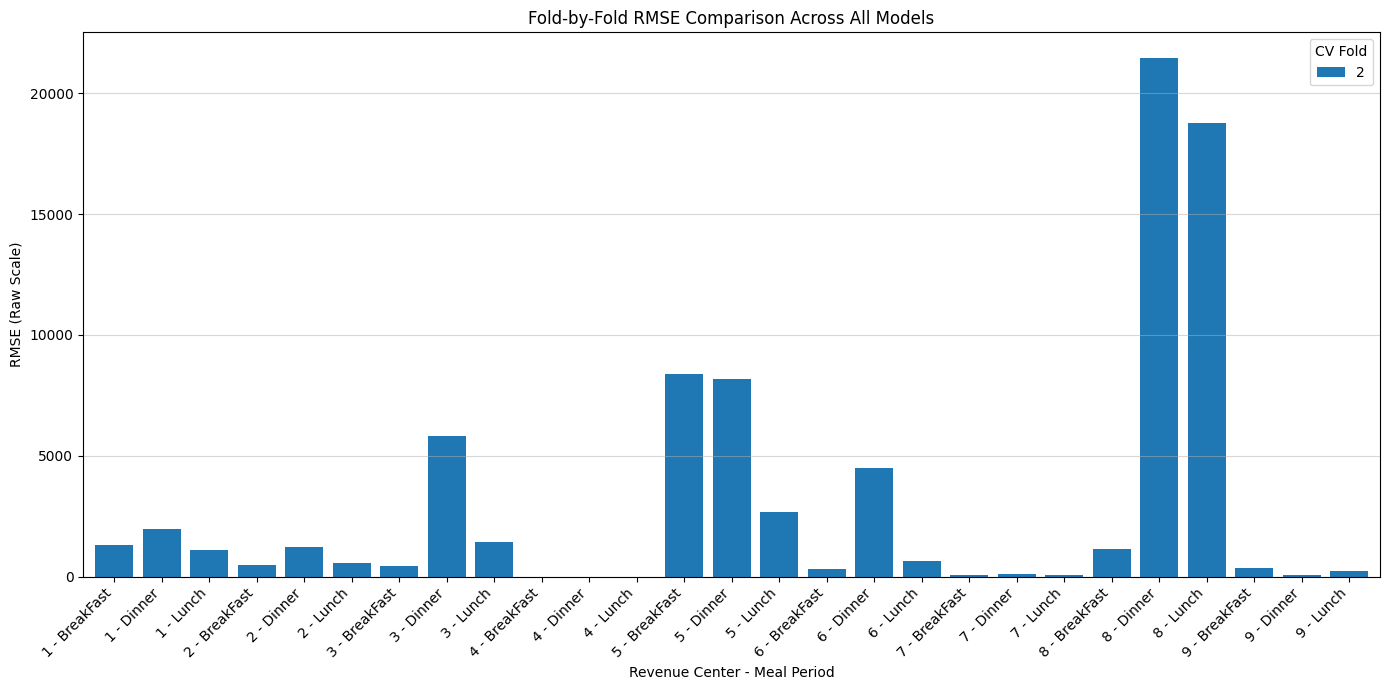

In [7]:
# --- Execute Training Across Centers ---
print("--- STARTING EXECUTION: Optuna Optimization (TPE Sampler) ---")
try:
    if not os.path.exists(OUTPUT_FILE_NAME):
        raise FileNotFoundError(f"File not found at path: {OUTPUT_FILE_NAME}")
    xls = pd.ExcelFile(OUTPUT_FILE_NAME)
    REVENUE_CENTERS = xls.sheet_names
    print(f"✅ SUCCESS: Loaded {len(REVENUE_CENTERS)} revenue centers (sheets).")
except FileNotFoundError as e:
    print(f"❌ ERROR: File Not Found. Please check the path and ensure the file is uploaded/mounted. {e}")
    REVENUE_CENTERS = []
except Exception as e:
    print(f"❌ ERROR loading Excel file: {e}")
    REVENUE_CENTERS = []

# Suppress Optuna output verbosity for cleaner console logs
optuna.logging.set_verbosity(optuna.logging.WARN)

for center_name in REVENUE_CENTERS:
    df_center = pd.read_excel(OUTPUT_FILE_NAME, sheet_name=center_name)
    df_center['Date'] = pd.to_datetime(df_center['Date'])
    required_cols = ['Date'] + TARGET_RAW_COLS
    if not all(col in df_center.columns for col in required_cols):
        print(f"❌ FAILED: Center {center_name} is missing essential columns. Skipping.")
        continue
    train_and_forecast_center(df_center, center_name)

# --- Post-Training Diagnostics ---
if REVENUE_CENTERS:
    print("\n\n" + "="*80)
    print("🥇 FINAL HYPERPARAMETER COMPARISON TABLE (Optuna TPE)")
    print("="*80)

    df_comp = pd.DataFrame(optuna_final_comparison_results).sort_values(['Center', 'Meal', 'Avg_CV_RMSE'])

    df_comp['Best_Alpha'] = df_comp['Best_Alpha'].map('{:.2f}'.format)
    df_comp['Best_LR'] = df_comp['Best_LR'].map('{:.5f}'.format)
    df_comp['Best_MD'] = df_comp['Best_MD'].astype(int) # Ensure MD is clean integer
    df_comp['Avg_CV_RMSE'] = df_comp['Avg_CV_RMSE'].map('{:.2f}'.format)

    print(df_comp.to_markdown(index=False))

    print("\n--- VISUALIZING CROSS-VALIDATION ROBUSTNESS ---")
    plot_cv_rmse_comparison(cv_results_list)